# Defining base dataset (all features)

In [1]:
import os
from typing import Callable, Optional, Sequence, List, Dict, Any

import numpy as np
import pandas as pd

# =========================
# 1) Feature blocks to keep
# =========================

# ---- B0: language-independent ----
B0_SUMMARY = [
    "file_length",
    "speech_length_minutes",
    "speech_length_words",
    "words_per_min",
    "speech_percentage",
    "mean_pre_word_pause",
    "mean_pause_variability",
    "word_repeat_percentage",
    "phrase_repeat_percentage",
    # optional session/turn aggregates (still language-independent)
    "num_turns",
    "num_one_word_turns",
    "mean_turn_length_minutes",
    "mean_turn_length_words",
    "mean_pre_turn_pause",
    "speaker_percentage",
    "num_interrupts",
]

B0_TURNS = [
    "pre_turn_pause",
    "turn_length_minutes",
    "turn_length_words",
    "words_per_min",
    "speech_percentage",
    "mean_pause_length",
    "pause_variability",
    "word_repeat_percentage",
    "phrase_repeat_percentage",
    "interrupt_flag",
]

# ---- L: language-dependent ----
L_SUMMARY = [
    # English-only style (as present in your summary files)
    "syllables_per_min",
    "sentiment_pos",
    "sentiment_neg",
    "sentiment_neu",
    "sentiment_overall",
    "mattr_5",
    "mattr_10",
    "mattr_25",
    "mattr_50",
    "mattr_100",
    "first_person_percentage",
    "first_person_sentiment_positive",
    "first_person_sentiment_negative",
    "first_person_sentiment_overall",
    # Word-level coherence aggregates
    "word_coherence_mean",
    "word_coherence_var",
    "word_coherence_5_mean",
    "word_coherence_5_var",
    "word_coherence_10_mean",
    "word_coherence_10_var",
    # variability k=2..10
    *[f"word_coherence_variability_{k}_mean" for k in range(2, 11)],
    *[f"word_coherence_variability_{k}_var" for k in range(2, 11)],
    # Turn-level discourse aggregates
    "first_order_sentence_tangeniality_mean",
    "first_order_sentence_tangeniality_var",
    "second_order_sentence_tangeniality_mean",
    "second_order_sentence_tangeniality_var",
    "turn_to_turn_tangeniality_mean",
    "turn_to_turn_tangeniality_var",
    "turn_to_turn_tangeniality_slope",
    "semantic_perplexity_mean",
    "semantic_perplexity_var",
    "semantic_perplexity_5_mean",
    "semantic_perplexity_5_var",
    "semantic_perplexity_11_mean",
    "semantic_perplexity_11_var",
    "semantic_perplexity_15_mean",
    "semantic_perplexity_15_var",
]

L_TURNS = [
    "syllables_per_min",
    "sentiment_pos",
    "sentiment_neg",
    "sentiment_neu",
    "sentiment_overall",
    "mattr_5",
    "mattr_10",
    "mattr_25",
    "mattr_50",
    "mattr_100",
    "first_person_percentage",
    "first_person_sentiment_positive",
    "first_person_sentiment_negative",
    # discourse (per-turn)
    "first_order_sentence_tangeniality",
    "second_order_sentence_tangeniality",
    "turn_to_turn_tangeniality",
    "semantic_perplexity",
    "semantic_perplexity_5",
    "semantic_perplexity_11",
    "semantic_perplexity_15",
]


# =========================
# 2) One function (similar to yours)
# =========================

def _unique_preserve_order(items: Sequence[str]) -> List[str]:
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def merge_turns_and_summary_featureblock(
    detailed_labels_path: str,
    data_dir: str,
    *,
    participant_col: str = "Participant",
    turns_cols: Optional[List[str]] = None,
    summary_cols: Optional[List[str]] = None,
    turns_prefix: str = "turns_",
    summary_prefix: str = "summary_sc_",
    turns_suffix: str = ".csv",
    summary_suffix: str = ".csv",
    turns_agg: str | Callable[[pd.Series], Any] = "mean",   # "mean" | "first" | callable
    resolve_name_collisions: bool = True,                  # prevent overwriting when col exists in both
    turns_collision_suffix: str = "_turns",
    summary_collision_suffix: str = "_summary",
    # optional: if your turns files still include speaker rows, set these
    turns_speaker_col: Optional[str] = None,               # e.g. "speaker_label"
    participant_speaker_value: Optional[str] = None,       # e.g. "Participant"
    verbose: bool = False,
) -> pd.DataFrame:
    """
    Merge specified feature columns from turns_<pid>.csv and summary_sc_<pid>.csv into the labels table.
    - Aggregates turns columns per participant (default: mean).
    - Takes summary columns from the first row (file-level).
    - Resolves name collisions by suffixing if requested.
    """
    if os.path.isfile(data_dir):
        data_dir = os.path.dirname(data_dir)
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    df_labels = pd.read_csv(detailed_labels_path)
    df_labels[participant_col] = pd.to_numeric(df_labels[participant_col], errors="coerce").astype("Int64")

    pids = df_labels[participant_col].dropna().unique().astype(int)

    # keep list order stable, remove duplicates
    turns_cols = _unique_preserve_order(turns_cols or [])
    summary_cols = _unique_preserve_order(summary_cols or [])

    rows: List[Dict[str, Any]] = []
    for pid in pids:
        rec: Dict[str, Any] = {participant_col: pid}

        # ---------- turns_<pid>.csv ----------
        t_path = os.path.join(data_dir, f"{turns_prefix}{pid}{turns_suffix}")
        if os.path.exists(t_path) and turns_cols:
            t_header = pd.read_csv(t_path, nrows=0).columns.tolist()
            t_use = [c for c in turns_cols if c in t_header]

            # ensure speaker column is included if filtering is requested
            if turns_speaker_col and turns_speaker_col in t_header and turns_speaker_col not in t_use:
                t_use_with_speaker = [turns_speaker_col] + t_use
            else:
                t_use_with_speaker = t_use

            if t_use:
                t_df = pd.read_csv(t_path, usecols=t_use_with_speaker)

                # optional speaker filtering
                if turns_speaker_col and participant_speaker_value is not None and turns_speaker_col in t_df.columns:
                    t_df = t_df[t_df[turns_speaker_col] == participant_speaker_value].copy()

                # aggregate
                t_vals: Dict[str, Any] = {}
                if callable(turns_agg):
                    for c in t_use:
                        t_vals[c] = turns_agg(t_df[c])
                elif turns_agg == "mean":
                    for c in t_use:
                        col = pd.to_numeric(t_df[c], errors="coerce")
                        t_vals[c] = float(col.mean()) if len(col) else np.nan
                elif turns_agg == "first":
                    for c in t_use:
                        t_vals[c] = t_df[c].iloc[0] if len(t_df) else np.nan
                else:
                    raise ValueError(f"Unsupported turns_agg: {turns_agg!r}")

                # collision-safe naming (prevents overwriting later)
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in t_vals.items():
                        out_k = k if k not in rec else f"{k}{turns_collision_suffix}"
                        renamed[out_k] = v
                    t_vals = renamed

                rec.update(t_vals)
            elif verbose:
                print(f"[pid={pid}] turns file exists but none of requested cols found.")

        # ---------- summary_sc_<pid>.csv ----------
        s_path = os.path.join(data_dir, f"{summary_prefix}{pid}{summary_suffix}")
        if os.path.exists(s_path) and summary_cols:
            s_header = pd.read_csv(s_path, nrows=0).columns.tolist()
            s_use = [c for c in summary_cols if c in s_header]
            if s_use:
                s_df = pd.read_csv(s_path, usecols=s_use)
                s_vals = {c: (s_df[c].iloc[0] if len(s_df) else np.nan) for c in s_use}

                # collision-safe naming
                if resolve_name_collisions:
                    renamed = {}
                    for k, v in s_vals.items():
                        out_k = k if k not in rec else f"{k}{summary_collision_suffix}"
                        renamed[out_k] = v
                    s_vals = renamed

                rec.update(s_vals)
            elif verbose:
                print(f"[pid={pid}] summary file exists but none of requested cols found.")

        rows.append(rec)

    df_feat = pd.DataFrame(rows)
    df_out = df_labels.merge(df_feat, on=participant_col, how="left")
    return df_out

# =========================
# 3) Build 3 datasets by calling the same function
# =========================

def _union(a: List[str], b: List[str]) -> List[str]:
    return _unique_preserve_order(list(a) + list(b))

# pipeline for training models and checking feature importance

In [2]:
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Sequence, Dict, Any, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, cross_val_score

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
xgb_available = True


# -------------------------
# Bootstrap CIs
# -------------------------
def bootstrap_ci_binary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    metric: str,
    n_boot: int = 2000,
    seed: int = 1706,
    stratified: bool = True,
) -> Tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return float("nan"), float("nan"), float("nan")

    scores = []
    for _ in range(n_boot):
        if stratified:
            samp_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
            samp_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
            idx = np.concatenate([samp_pos, samp_neg])
        else:
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)

        yt, yp, pr = y_true[idx], y_pred[idx], y_proba[idx]
        if metric == "f1_macro":
            s = f1_score(yt, yp, average="macro")
        elif metric == "auc":
            if len(np.unique(yt)) < 2:
                continue
            s = roc_auc_score(yt, pr)
        else:
            raise ValueError("metric must be 'f1_macro' or 'auc'")
        scores.append(s)

    if not scores:
        return float("nan"), float("nan"), float("nan")

    lo, hi = np.percentile(scores, [2.5, 97.5])
    return float(np.mean(scores)), float(lo), float(hi)


# -------------------------
# Standardized leakage-safe drop builder
# -------------------------
def build_standard_drop_cols(
    df: pd.DataFrame,
    *,
    target_col: str,
    split_col: str = "split",
    id_col: str = "Participant",
    drop_demographics: bool = True,
    extra_drop: Optional[Sequence[str]] = None,
) -> List[str]:
    """
    Стандартизированный drop для бинарного таргета:
      - всегда: id_col, split_col, target_col
      - всегда: все *_label кроме target_col
      - всегда: все колонки с 'severity' в имени (любой таргет)
      - опционально: age/sex/gender
      - + extra_drop (если передано)
    """
    drop = set()

    # base/meta
    for c in [id_col, split_col, target_col]:
        if c in df.columns:
            drop.add(c)

    # labels (avoid "other ground-truth labels" leakage)
    for c in df.columns:
        cl = c.lower()
        if cl.endswith("_label") and c != target_col:
            drop.add(c)

    # severity-like columns (avoid "target proxy" leakage)
    for c in df.columns:
        if "severity" in c.lower():
            drop.add(c)

    # demographics (optional)
    if drop_demographics:
        for c in ["age", "sex", "gender"]:
            if c in df.columns:
                drop.add(c)

    if extra_drop:
        for c in extra_drop:
            if c in df.columns:
                drop.add(c)

    return sorted(drop)


def assert_no_leakage_cols_left(X: pd.DataFrame) -> None:
    bad = []
    for c in X.columns:
        cl = c.lower()
        if cl.endswith("_label") or "severity" in cl or cl == "split":
            bad.append(c)
    if bad:
        raise ValueError(
            "Leakage columns detected in features X (you must drop them): "
            + ", ".join(sorted(set(bad)))
        )


# -------------------------
# Main pipeline
# -------------------------
def run_models_pipeline_more_models_tuned_rocauc(
    dataset_path: str,
    *,
    target_col: str = "Depression_label",
    split_col: str = "split",
    id_col: str = "Participant",
    train_values: Sequence[str] = ("train", "dev"),
    test_value: str = "test",

    # If provided -> used as EXTRA drops in addition to standardized drops.
    drop_cols: Optional[Sequence[str]] = None,

    # Standardization controls
    drop_demographics: bool = True,

    random_state: int = 1706,
    n_boot: int = 2000,

    compute_importance: bool = True,
    perm_scoring: str = "roc_auc",
    perm_n_repeats: int = 10,
    plot_top_k: int = 15,

    # train-only feature selection
    train_on_importance: bool = True,
    importance_top_k: int = 30,
    importance_corr_thr: float = 0.90,
    importance_n_repeats: int = 20,
    importance_cv_splits: int = 5,

    # grid search for tree-based models
    tune_tree_models: bool = True,
    cv_splits: int = 5,
    grid_scoring: str = "roc_auc",
    grid_n_jobs: int = 1,
    grid_verbose: int = 0,

    # report CV AUC for ALL models on train+dev
    report_train_cv_auc: bool = True,
) -> pd.DataFrame:
    """
    Standardized version: drop_cols is automatically constructed from the selected target_col,
    so that there are no leaks (other *_label, severity, split, id).
    """

    df = pd.read_csv(dataset_path)

    if split_col not in df.columns:
        raise KeyError(f"Missing '{split_col}' column in dataset: {dataset_path}")
    if target_col not in df.columns:
        raise KeyError(f"Missing target_col='{target_col}' in dataset: {dataset_path}")

    # --- build standardized drops ---
    std_drop = build_standard_drop_cols(
        df,
        target_col=target_col,
        split_col=split_col,
        id_col=id_col,
        drop_demographics=drop_demographics,
        extra_drop=drop_cols,
    )

    # --- split ---
    split_lower = df[split_col].astype(str).str.lower().str.strip()
    train_values_set = {str(v).lower() for v in train_values}
    is_train = split_lower.isin(train_values_set)
    is_test = split_lower.eq(str(test_value).lower())

    if is_train.sum() == 0 or is_test.sum() == 0:
        raise ValueError(
            f"Train/Test rows not found. train in {sorted(train_values_set)} count={is_train.sum()}, "
            f"test='{test_value}' count={is_test.sum()}."
        )

    # --- y ---
    y_train = df.loc[is_train, target_col].astype(int).to_numpy()
    y_test = df.loc[is_test, target_col].astype(int).to_numpy()

    # sanity: binary
    uniq = np.unique(y_train)
    if len(uniq) != 2:
        raise ValueError(f"Target '{target_col}' is not binary on train+dev. Unique values: {uniq}")

    # --- X ---
    X_train = df.loc[is_train].drop(columns=std_drop, errors="ignore")
    X_test = df.loc[is_test].drop(columns=std_drop, errors="ignore")

    if X_train.shape[1] == 0:
        raise ValueError("No features left after dropping standardized leakage/meta columns.")

    # hard guard: make sure nothing leaky stayed
    assert_no_leakage_cols_left(X_train)

    # -------------------------
    # helpers
    # -------------------------
    def _build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
        categorical_cols = [c for c in X.columns if X[c].dtype.name in ["object", "category", "bool"]]
        numeric_cols = [c for c in X.columns if c not in categorical_cols]

        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

        cat_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("enc", ohe),
        ])
        num_pipe = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ])

        pre = ColumnTransformer(
            transformers=[
                ("cat", cat_pipe, categorical_cols),
                ("num", num_pipe, numeric_cols),
            ],
            remainder="drop"
        )
        return pre, categorical_cols, numeric_cols

    def _predict_proba_or_score(pipe: Pipeline, X: pd.DataFrame) -> Optional[np.ndarray]:
        try:
            return pipe.predict_proba(X)[:, 1]
        except Exception:
            try:
                from scipy.special import expit
                return expit(pipe.decision_function(X))
            except Exception:
                return None

    def _metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: Optional[np.ndarray]) -> Dict[str, Any]:
        out = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
            "balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
            "roc_auc": float("nan"),
            "pr_auc": float("nan"),
            "brier": float("nan"),
            "f1_lo": float("nan"),
            "f1_hi": float("nan"),
            "auc_lo": float("nan"),
            "auc_hi": float("nan"),
        }
        if y_proba is not None and len(np.unique(y_true)) == 2:
            out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
            out["pr_auc"] = float(average_precision_score(y_true, y_proba))
            out["brier"] = float(brier_score_loss(y_true, y_proba))

            _, f1_lo, f1_hi = bootstrap_ci_binary(y_true, y_pred, y_proba, metric="f1_macro", n_boot=n_boot, seed=random_state)
            _, auc_lo, auc_hi = bootstrap_ci_binary(y_true, y_pred, y_proba, metric="auc", n_boot=n_boot, seed=random_state)
            out["f1_lo"], out["f1_hi"] = float(f1_lo), float(f1_hi)
            out["auc_lo"], out["auc_hi"] = float(auc_lo), float(auc_hi)
        return out

    def _safe_cv_splits(y: np.ndarray, desired: int) -> int:
        counts = Counter(y.tolist())
        min_class = min(counts.values()) if counts else 0
        return max(2, min(desired, min_class)) if min_class >= 2 else 0

    def _cv_auc(pipe: Pipeline, X: pd.DataFrame, y: np.ndarray, desired_splits: int) -> Tuple[float, float]:
        k = _safe_cv_splits(y, desired_splits)
        if k < 2:
            return float("nan"), float("nan")
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        scores = cross_val_score(clone(pipe), X, y, cv=cv, scoring="roc_auc", n_jobs=1)
        return float(np.mean(scores)), float(np.std(scores))

    def _warn_if_degenerate_proba(y_proba: Optional[np.ndarray], title: str) -> None:
        if y_proba is None:
            return
        uniqp = np.unique(np.round(y_proba, 6))
        if len(uniqp) <= 5:
            print(f"[WARN] {title}: very few unique predicted probabilities ({len(uniqp)}).")

    def _perm_importance_raw(pipe: Pipeline, X_eval: pd.DataFrame, y_eval: np.ndarray, title: str) -> None:
        try:
            perm = permutation_importance(
                pipe, X_eval, y_eval,
                n_repeats=perm_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            perm_df = pd.DataFrame({
                "feature": list(X_eval.columns),
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std,
            }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

            print(f"\n[{title}] Top-{min(10, len(perm_df))} permutation importances ({perm_scoring}, raw):")
            print(perm_df.head(10).to_string(index=False))

            top_n = min(plot_top_k, len(perm_df))
            if top_n > 0:
                plt.figure(figsize=(9, max(4, 0.35 * top_n)))
                plt.barh(
                    perm_df.loc[:top_n - 1, "feature"][::-1],
                    perm_df.loc[:top_n - 1, "importance_mean"][::-1],
                )
                plt.title(f"Permutation importance (top-{top_n}) — {title} [raw]")
                plt.xlabel(f"Mean importance on EVAL ({perm_scoring})")
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"[{title}] permutation importance failed: {e}")

    def _select_cols_train_only_cv(base_pipe: Pipeline, X_tr: pd.DataFrame, y_tr: np.ndarray) -> List[str]:
        k = _safe_cv_splits(y_tr, importance_cv_splits)
        if k < 2:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
            (idx_sub, idx_val), = sss.split(X_tr, y_tr)
            X_sub, y_sub = X_tr.iloc[idx_sub], y_tr[idx_sub]
            X_val, y_val = X_tr.iloc[idx_val], y_tr[idx_val]

            pipe = clone(base_pipe)
            pipe.fit(X_sub, y_sub)
            perm = permutation_importance(
                pipe, X_val, y_val,
                n_repeats=importance_n_repeats,
                random_state=random_state,
                scoring=perm_scoring
            )
            imp = pd.Series(perm.importances_mean, index=X_val.columns)
        else:
            cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
            imp_accum = pd.Series(0.0, index=X_tr.columns)
            folds = 0
            for tr_idx, val_idx in cv.split(X_tr, y_tr):
                X_sub, y_sub = X_tr.iloc[tr_idx], y_tr[tr_idx]
                X_val, y_val = X_tr.iloc[val_idx], y_tr[val_idx]
                pipe = clone(base_pipe)
                pipe.fit(X_sub, y_sub)
                perm = permutation_importance(
                    pipe, X_val, y_val,
                    n_repeats=importance_n_repeats,
                    random_state=random_state,
                    scoring=perm_scoring
                )
                imp_accum = imp_accum.add(pd.Series(perm.importances_mean, index=X_val.columns), fill_value=0.0)
                folds += 1
            imp = imp_accum / max(folds, 1)

        imp = imp.sort_values(ascending=False)
        cand = imp.head(max(1, importance_top_k)).index.tolist()

        # correlation pruning on numeric subset
        X_cand = X_tr[cand]
        num_cols = X_cand.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) > 1:
            corr = X_cand[num_cols].corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            to_drop = set()
            for c in upper.columns:
                for r in upper.index[upper[c] > importance_corr_thr].tolist():
                    drop = c if imp.get(c, -np.inf) < imp.get(r, -np.inf) else r
                    to_drop.add(drop)
            cand = [c for c in cand if c not in to_drop]

        if not cand:
            cand = imp.head(5).index.tolist()
        return cand

    def _grid_search_tree_if_enabled(
        *,
        estimator,
        preprocessor: ColumnTransformer,
        X_tr: pd.DataFrame,
        y_tr: np.ndarray,
        param_grid: Dict[str, List[Any]],
    ):
        pipe = Pipeline([("pre", preprocessor), ("clf", clone(estimator))])

        if (not tune_tree_models) or (not param_grid):
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cvk = _safe_cv_splits(y_tr, cv_splits)
        if cvk < 2:
            pipe.fit(X_tr, y_tr)
            return pipe, {}, float("nan"), False

        cv = StratifiedKFold(n_splits=cvk, shuffle=True, random_state=random_state)
        grid = {f"clf__{k}": v for k, v in param_grid.items()}

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring=grid_scoring,
            cv=cv,
            n_jobs=grid_n_jobs,
            refit=True,
            verbose=grid_verbose,
            error_score=np.nan
        )
        gs.fit(X_tr, y_tr)
        return gs.best_estimator_, gs.best_params_, float(gs.best_score_), True

    # -------------------------
    # models + grids
    # -------------------------
    models: List[Tuple[str, Any, bool, Dict[str, List[Any]]]] = []

    models.append(("LogisticRegression", LogisticRegression(
        solver="saga", max_iter=5000, class_weight="balanced",
        random_state=random_state, n_jobs=1
    ), False, {}))

    models.append(("SGDClassifier(log_loss)", SGDClassifier(
        loss="log_loss", penalty="l2", alpha=1e-4,
        max_iter=5000, tol=1e-3, class_weight="balanced",
        random_state=random_state
    ), False, {}))

    models.append(("DecisionTree", DecisionTreeClassifier(
        random_state=random_state, class_weight="balanced"
    ), True, {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4, 8],
    }))

    models.append(("RandomForest", RandomForestClassifier(
        random_state=random_state, class_weight="balanced", n_jobs=1
    ), True, {
        "n_estimators": [200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5],
        "bootstrap": [True],
    }))

    if xgb_available:
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        spw = float(neg / max(pos, 1)) if pos > 0 else 1.0

        base_xgb = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=random_state,
            n_jobs=1,
            scale_pos_weight=spw,
        )
        models.append(("XGBoost", base_xgb, True, {
            "n_estimators": [200, 500],
            "max_depth": [3, 6, 10],
            "learning_rate": [0.03, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "min_child_weight": [1, 5],
            "reg_lambda": [1.0, 5.0],
        }))

    # -------------------------
    # run
    # -------------------------
    print(f"\n[INFO] target_col = {target_col}")
    print(f"[INFO] standardized drop_cols ({len(std_drop)}): {std_drop}")
    print(f"[INFO] X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
    print(f"[INFO] class counts train: {np.bincount(y_train)} | test: {np.bincount(y_test)}")

    results: List[Dict[str, Any]] = []

    for model_name, estimator, is_tree, grid in models:
        # ===== FULL =====
        pre, _, _ = _build_preprocessor(X_train)

        if is_tree:
            pipe_full, best_params, best_cv, tuned = _grid_search_tree_if_enabled(
                estimator=estimator,
                preprocessor=pre,
                X_tr=X_train,
                y_tr=y_train,
                param_grid=grid
            )
        else:
            pipe_full = Pipeline([("pre", pre), ("clf", clone(estimator))])
            pipe_full.fit(X_train, y_train)
            best_params, best_cv, tuned = {}, float("nan"), False

        cv_auc_mean, cv_auc_std = (float("nan"), float("nan"))
        if report_train_cv_auc:
            cv_auc_mean, cv_auc_std = _cv_auc(pipe_full, X_train, y_train, desired_splits=cv_splits)

        y_pred = pipe_full.predict(X_test)
        y_proba = _predict_proba_or_score(pipe_full, X_test)
        _warn_if_degenerate_proba(y_proba, f"{model_name}[full]")

        row_full = {
            "dataset": dataset_path,
            "target": target_col,
            "model": model_name,
            "variant": "full_tuned" if tuned else "full",
            "tuned": bool(tuned),
            "cv_best_score": best_cv,
            "cv_auc_mean": cv_auc_mean,
            "cv_auc_std": cv_auc_std,
            "best_params": str(best_params) if best_params else "",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "n_features_raw": int(X_train.shape[1]),
            "n_features_selected": np.nan,
            "selected_cols": "",
            **_metrics(y_test, y_pred, y_proba)
        }

        print(f"\n=== {model_name} [{row_full['variant']}] ({dataset_path}) ===")
        if tuned:
            print("Best CV score:", round(best_cv, 4), "Best params:", best_params)
        if report_train_cv_auc:
            print("Train+Dev CV AUC:", row_full["cv_auc_mean"], "+/-", row_full["cv_auc_std"])
        print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

        if compute_importance:
            _perm_importance_raw(pipe_full, X_test, y_test, f"{model_name} [{row_full['variant']}]")

        results.append(row_full)

        # ===== SELECTED =====
        if train_on_importance:
            pre_sel, _, _ = _build_preprocessor(X_train)
            base_pipe = Pipeline([("pre", pre_sel), ("clf", clone(estimator))])

            selected_cols = _select_cols_train_only_cv(base_pipe, X_train, y_train)

            X_train_sel = X_train[selected_cols].copy()
            X_test_sel = X_test[selected_cols].copy()

            pre2, _, _ = _build_preprocessor(X_train_sel)

            if is_tree:
                pipe_sel, best_params2, best_cv2, tuned2 = _grid_search_tree_if_enabled(
                    estimator=estimator,
                    preprocessor=pre2,
                    X_tr=X_train_sel,
                    y_tr=y_train,
                    param_grid=grid
                )
            else:
                pipe_sel = Pipeline([("pre", pre2), ("clf", clone(estimator))])
                pipe_sel.fit(X_train_sel, y_train)
                best_params2, best_cv2, tuned2 = {}, float("nan"), False

            cv_auc_mean2, cv_auc_std2 = (float("nan"), float("nan"))
            if report_train_cv_auc:
                cv_auc_mean2, cv_auc_std2 = _cv_auc(pipe_sel, X_train_sel, y_train, desired_splits=cv_splits)

            y_pred2 = pipe_sel.predict(X_test_sel)
            y_proba2 = _predict_proba_or_score(pipe_sel, X_test_sel)
            _warn_if_degenerate_proba(y_proba2, f"{model_name}[selected]")

            row_sel = {
                "dataset": dataset_path,
                "target": target_col,
                "model": model_name,
                "variant": "selected_tuned" if tuned2 else f"selected(top={importance_top_k},corr<{importance_corr_thr})",
                "tuned": bool(tuned2),
                "cv_best_score": best_cv2,
                "cv_auc_mean": cv_auc_mean2,
                "cv_auc_std": cv_auc_std2,
                "best_params": str(best_params2) if best_params2 else "",
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "n_features_raw": int(X_train.shape[1]),
                "n_features_selected": int(len(selected_cols)),
                "selected_cols": ",".join(selected_cols),
                **_metrics(y_test, y_pred2, y_proba2)
            }

            print(f"\n=== {model_name} [{row_sel['variant']}] ({dataset_path}) ===")
            print("Selected cols:", selected_cols)
            if tuned2:
                print("Best CV score:", round(best_cv2, 4), "Best params:", best_params2)
            if report_train_cv_auc:
                print("Train+Dev CV AUC:", row_sel["cv_auc_mean"], "+/-", row_sel["cv_auc_std"])
            print("\nClassification report:\n", classification_report(y_test, y_pred2, digits=3))
            print("Confusion matrix:\n", confusion_matrix(y_test, y_pred2))

            if compute_importance:
                _perm_importance_raw(pipe_sel, X_test_sel, y_test, f"{model_name} [{row_sel['variant']}]")

            results.append(row_sel)

    res_df = pd.DataFrame(results)[[
        "target", "model", "variant", "tuned", "cv_best_score", "cv_auc_mean", "cv_auc_std", "best_params",
        "n_train", "n_test",
        "n_features_raw", "n_features_selected",
        "accuracy", "f1_macro", "f1_lo", "f1_hi",
        "balanced_acc", "roc_auc", "auc_lo", "auc_hi",
        "pr_auc", "brier",
        "selected_cols"
    ]]

    print("\n=== Summary metrics on TEST ===")
    print(res_df.round(4).to_string(index=False))
    return res_df


# Training Gemma, eng, small feature set

### L

In [3]:
# ---- L: language-dependent ----
L_SUMMARY = [
    "turn_to_turn_tangeniality_mean",
    "turn_to_turn_tangeniality_slope",
    "word_coherence_mean",
    "first_order_sentence_tangeniality_mean",
    "semantic_perplexity_mean",
]

L_TURNS = [
    "syllables_per_min",
    "sentiment_pos",
    "sentiment_neg",
    "mattr_50",
    "first_person_percentage",
    "first_person_sentiment_negative",
    "mattr_10",
    "sentiment_overall",
]

# Paths (edit)
detailed_labels_path = "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/detailed_lables.csv"
data_dir = "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/result_oppenwillis_eng_norm_gemma"

# Columns you always want in the final CSVs (spine)
SPINE_COLS = ["Participant", "gender", "age", "split", "Depression_label", "PTSD_label", "PTSD_severity"]

# --- L ---
df_l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=L_TURNS,
    summary_cols=L_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,
)

L_OUT_COLS = [c for c in df_l.columns if c in SPINE_COLS] + \
            [c for c in df_l.columns if (c in L_TURNS or c.endswith("_turns"))] + \
            [c for c in df_l.columns if (c in L_SUMMARY or c.endswith("_summary"))]

df_l_out = df_l[_unique_preserve_order(L_OUT_COLS)].copy()
df_l_out.to_csv(
    "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv",
    index=False
)
df_l_out.columns

Index(['Participant', 'PTSD_severity', 'gender', 'age', 'Depression_label',
       'PTSD_label', 'split', 'syllables_per_min', 'sentiment_pos',
       'sentiment_neg', 'mattr_50', 'first_person_percentage',
       'first_person_sentiment_negative', 'mattr_10', 'sentiment_overall',
       'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope',
       'word_coherence_mean', 'first_order_sentence_tangeniality_mean',
       'semantic_perplexity_mean'],
      dtype='object')

### B0

In [4]:
B0_TURNS = [
    "words_per_min",
    "speech_percentage",
]

B0_SUMMARY = [
    "mean_pre_word_pause",
    "mean_pause_variability",
    "mean_pre_turn_pause",
    "mean_turn_length_words",
    "speech_length_minutes",
]
# --- B0 ---
df_b0 = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=B0_TURNS,
    summary_cols=B0_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,  # keeps both turns+summary if same name exists
)

b0_feature_cols = _unique_preserve_order(
    [c for c in df_b0.columns if c not in df_b0.columns.difference(df_b0.columns)]  # noop, keep below
)
# safer: explicitly compute expected output cols by checking presence
B0_OUT_COLS = [c for c in df_b0.columns if c in SPINE_COLS] + \
             [c for c in df_b0.columns if (c in B0_TURNS or c.endswith("_turns"))] + \
             [c for c in df_b0.columns if (c in B0_SUMMARY or c.endswith("_summary"))]

df_b0_out = df_b0[_unique_preserve_order(B0_OUT_COLS)].copy()
df_b0_out.to_csv(
    "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv",
    index=False
)
df_b0_out.columns

Index(['Participant', 'PTSD_severity', 'gender', 'age', 'Depression_label',
       'PTSD_label', 'split', 'words_per_min', 'speech_percentage',
       'mean_pre_word_pause', 'mean_pause_variability', 'mean_pre_turn_pause',
       'mean_turn_length_words', 'speech_length_minutes'],
      dtype='object')

### B0+L

In [ ]:
# --- B0 + L ---
df_b0l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=_union(B0_TURNS, L_TURNS),
    summary_cols=_union(B0_SUMMARY, L_SUMMARY),
    turns_agg="mean",
    resolve_name_collisions=True,
)

B0L_OUT_COLS = [c for c in df_b0l.columns if c in SPINE_COLS] + \
              [c for c in df_b0l.columns if (c in _union(B0_TURNS, L_TURNS) or c.endswith("_turns"))] + \
              [c for c in df_b0l.columns if (c in _union(B0_SUMMARY, L_SUMMARY) or c.endswith("_summary"))]

df_b0l_out = df_b0l[_unique_preserve_order(B0L_OUT_COLS)].copy()
df_b0l_out.to_csv(
    "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv",
    index=False
)
df_b0l_out.columns

Index(['Participant', 'PTSD_severity', 'gender', 'age', 'Depression_label',
       'PTSD_label', 'split', 'words_per_min', 'speech_percentage',
       'syllables_per_min', 'sentiment_pos', 'sentiment_neg', 'mattr_50',
       'first_person_percentage', 'first_person_sentiment_negative',
       'mattr_10', 'sentiment_overall', 'mean_pre_word_pause',
       'mean_pause_variability', 'mean_pre_turn_pause',
       'mean_turn_length_words', 'speech_length_minutes',
       'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope',
       'word_coherence_mean', 'first_order_sentence_tangeniality_mean',
       'semantic_perplexity_mean'],
      dtype='object')

## test result, target - PTSD


[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (7): ['Depression_label', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 13) | X_test shape: (56, 13)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Train+Dev CV AUC: 0.7165059671511285 +/- 0.055742737866758235

Classification report:
               precision    recall  f1-score   support

           0      0.800     0.686     0.738        35
           1      0.577     0.714     0.638        21

    accuracy                          0.696        56
   macro avg      0.688     0.700     0.688        56
weighted avg      0.716     0.696     0.701        56

Confusion matrix:
 [[24 11]
 [ 6 15]]

[LogisticRegression [full]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std

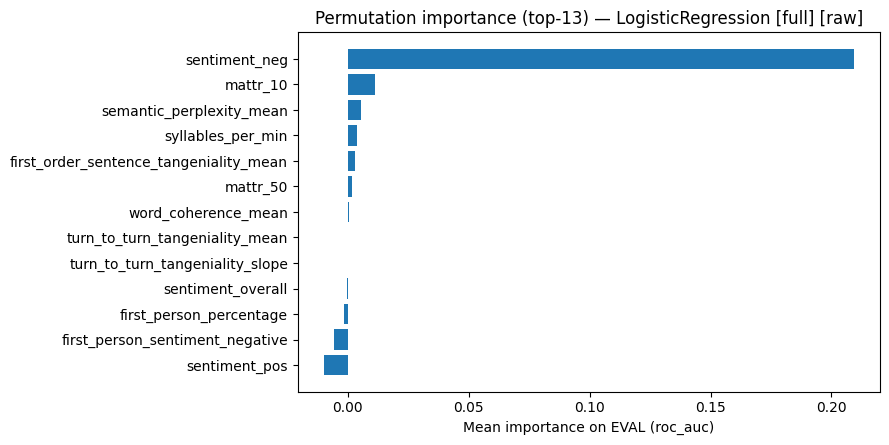


=== LogisticRegression [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Selected cols: ['sentiment_neg', 'sentiment_pos', 'first_order_sentence_tangeniality_mean', 'first_person_percentage', 'first_person_sentiment_negative', 'mattr_10', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'sentiment_overall', 'semantic_perplexity_mean', 'mattr_50', 'syllables_per_min']
Train+Dev CV AUC: 0.7160096892354957 +/- 0.05618616651558635

Classification report:
               precision    recall  f1-score   support

           0      0.774     0.686     0.727        35
           1      0.560     0.667     0.609        21

    accuracy                          0.679        56
   macro avg      0.667     0.676     0.668        56
weighted avg      0.694     0.679     0.683        56

Confusion matrix:
 [[24 11]
 [ 7 14]]

[LogisticRegression [selected(top=30,corr<0.9)]] Top-10 permutation importances

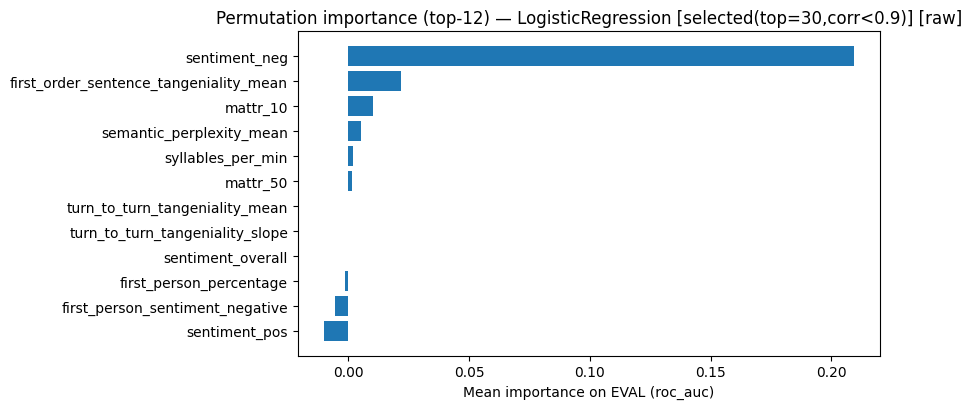


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Train+Dev CV AUC: 0.6755594942691717 +/- 0.08160193525939138

Classification report:
               precision    recall  f1-score   support

           0      0.769     0.571     0.656        35
           1      0.500     0.714     0.588        21

    accuracy                          0.625        56
   macro avg      0.635     0.643     0.622        56
weighted avg      0.668     0.625     0.630        56

Confusion matrix:
 [[20 15]
 [ 6 15]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (roc_auc, raw):
                        feature  importance_mean  importance_std
                  sentiment_neg         0.200408        0.042614
       semantic_perplexity_mean         0.024490        0.025417
              sentiment_overall         0.011973        0.016705
                       mattr_10         0.005170        0.018037
       

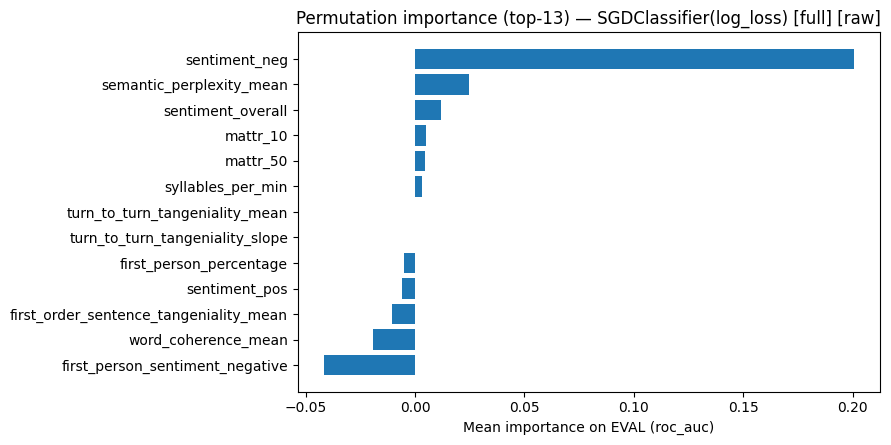


=== SGDClassifier(log_loss) [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Selected cols: ['sentiment_pos', 'sentiment_neg', 'first_order_sentence_tangeniality_mean', 'mattr_10', 'sentiment_overall', 'first_person_percentage', 'semantic_perplexity_mean', 'first_person_sentiment_negative', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'mattr_50', 'syllables_per_min']
Train+Dev CV AUC: 0.6224530308401277 +/- 0.09554846496181786

Classification report:
               precision    recall  f1-score   support

           0      0.719     0.657     0.687        35
           1      0.500     0.571     0.533        21

    accuracy                          0.625        56
   macro avg      0.609     0.614     0.610        56
weighted avg      0.637     0.625     0.629        56

Confusion matrix:
 [[23 12]
 [ 9 12]]

[SGDClassifier(log_loss) [selected(top=30,corr<0.9)]] Top-10 permutation i

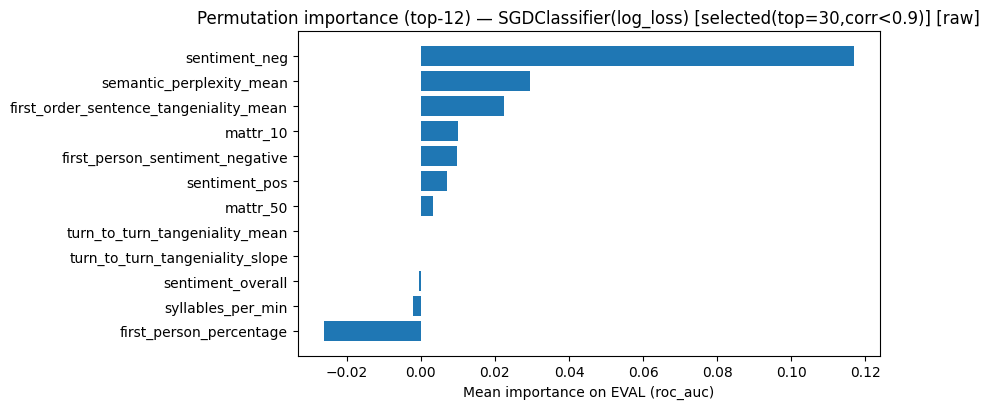


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Best CV score: 0.6499 Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.6498942455394067 +/- 0.0637004703301302

Classification report:
               precision    recall  f1-score   support

           0      0.595     0.629     0.611        35
           1      0.316     0.286     0.300        21

    accuracy                          0.500        56
   macro avg      0.455     0.457     0.456        56
weighted avg      0.490     0.500     0.494        56

Confusion matrix:
 [[22 13]
 [15  6]]

[DecisionTree [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.086395        0.040749
                         sentiment_pos         0.024422        0.048675
            

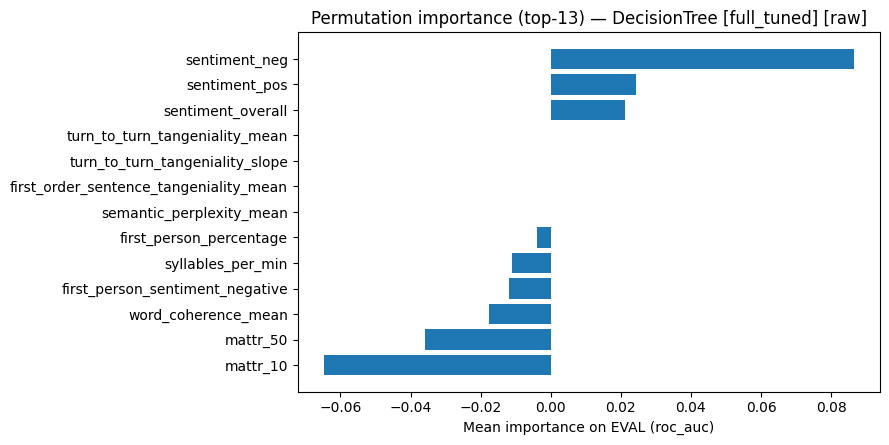


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Selected cols: ['sentiment_neg', 'sentiment_pos', 'semantic_perplexity_mean', 'first_person_sentiment_negative', 'first_order_sentence_tangeniality_mean', 'syllables_per_min', 'mattr_10', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'sentiment_overall', 'first_person_percentage', 'mattr_50']
Best CV score: 0.6376 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.6376444523218716 +/- 0.03486775586156599

Classification report:
               precision    recall  f1-score   support

           0      0.650     0.743     0.693        35
           1      0.438     0.333     0.378        21

    accuracy                          0.589        56
   macro avg      0.544     0.538     0.536        56
weighted avg      0.570     0.589     0.575        56

Confusion matrix:
 [[

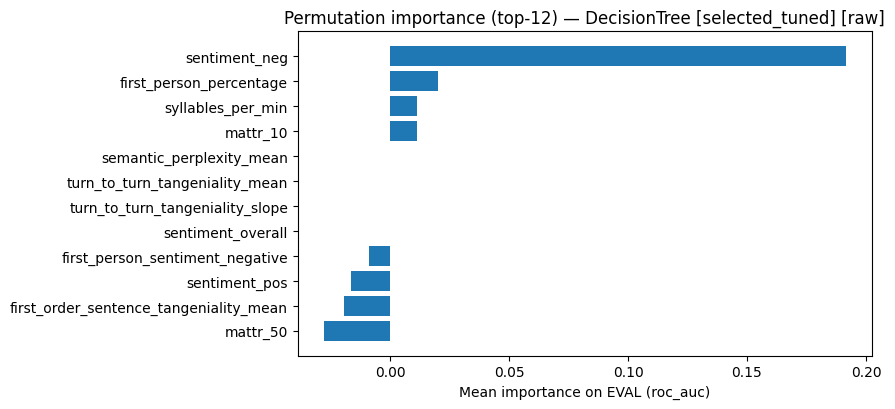


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Best CV score: 0.6916 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
Train+Dev CV AUC: 0.6916081767694671 +/- 0.039723288110095296

Classification report:
               precision    recall  f1-score   support

           0      0.683     0.800     0.737        35
           1      0.533     0.381     0.444        21

    accuracy                          0.643        56
   macro avg      0.608     0.590     0.591        56
weighted avg      0.627     0.643     0.627        56

Confusion matrix:
 [[28  7]
 [13  8]]

[RandomForest [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.106395        0.045536
   

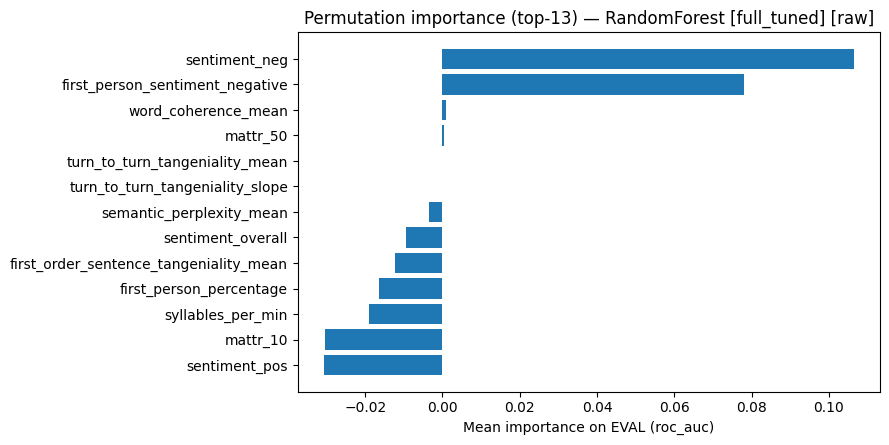


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Selected cols: ['sentiment_neg', 'sentiment_pos', 'first_person_sentiment_negative', 'mattr_10', 'semantic_perplexity_mean', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'word_coherence_mean', 'sentiment_overall', 'mattr_50', 'first_person_percentage', 'syllables_per_min']
Best CV score: 0.6948 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
Train+Dev CV AUC: 0.6948245303084013 +/- 0.02998975096187874

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.743     0.703        35
           1      0.471     0.381     0.421        21

    accuracy                          0.607        56
   macro avg      0.569     0.562     0.562        56
weighted avg      

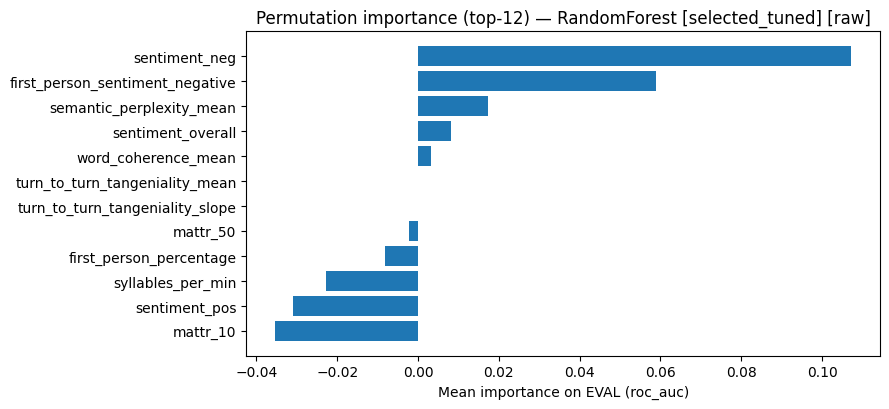


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Best CV score: 0.6659 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV AUC: 0.6659092520382843 +/- 0.045001516753055144

Classification report:
               precision    recall  f1-score   support

           0      0.647     0.629     0.638        35
           1      0.409     0.429     0.419        21

    accuracy                          0.554        56
   macro avg      0.528     0.529     0.528        56
weighted avg      0.558     0.554     0.556        56

Confusion matrix:
 [[22 13]
 [12  9]]

[XGBoost [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg     8.068027e-02        

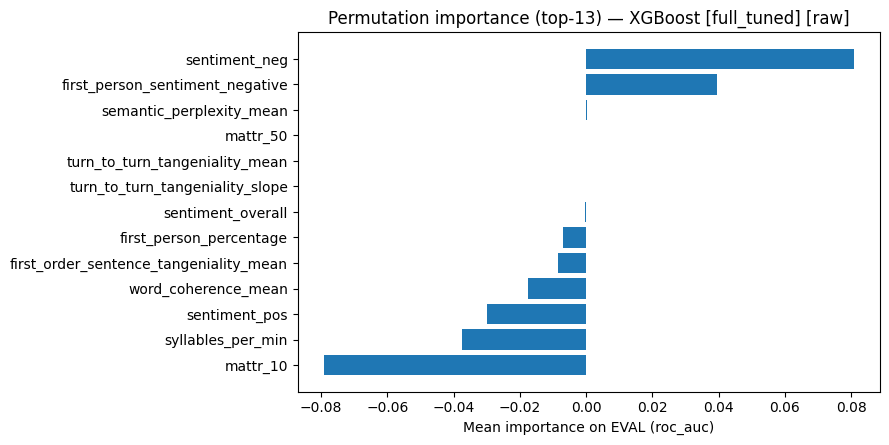


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv) ===
Selected cols: ['sentiment_neg', 'mattr_10', 'sentiment_pos', 'first_person_sentiment_negative', 'semantic_perplexity_mean', 'first_order_sentence_tangeniality_mean', 'first_person_percentage', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'sentiment_overall', 'mattr_50', 'syllables_per_min']
Best CV score: 0.6752 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV AUC: 0.6752333687817559 +/- 0.05576578269220893

Classification report:
               precision    recall  f1-score   support

           0      0.606     0.571     0.588        35
           1      0.348     0.381     0.364        21

    accuracy                          0.500        56
   macro avg      0.477     0.476

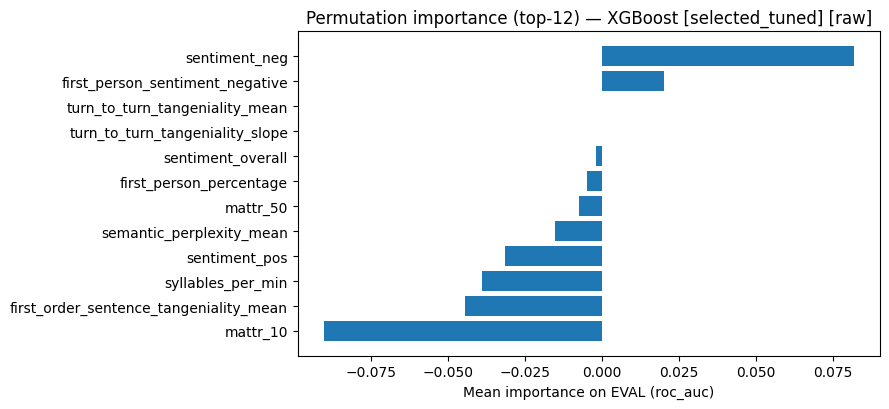


=== Summary metrics on TEST ===
    target                   model                   variant  tuned  cv_best_score  cv_auc_mean  cv_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                                                                                                                                                                                            selected_cols
PTSD_label      LogisticRegression                      full  False            NaN       0.7165      0.0557                                                                                                                                                                    

In [6]:
res_l_ptsd = run_models_pipeline_more_models_tuned_rocauc("/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_eng_add_small.csv", target_col="PTSD_label")

In [7]:
res_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_auc_mean,cv_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.716506,0.055743,,219,56,...,0.688380,0.566452,0.809524,0.700000,0.693878,0.548299,0.836735,0.587231,0.229175,
1,PTSD_label,LogisticRegression,"selected(top=30,corr<0.9)",False,NaN,0.716010,0.056186,,219,56,...,0.667984,0.547566,0.792383,0.676190,0.692517,0.545578,0.835408,0.586757,0.229395,"sentiment_neg,sentiment_pos,first_order_senten..."
2,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.675559,0.081602,,219,56,...,0.621986,0.497436,0.744792,0.642857,0.654422,0.515612,0.791837,0.459888,0.352657,
3,PTSD_label,SGDClassifier(log_loss),"selected(top=30,corr<0.9)",False,NaN,0.622453,0.095548,,219,56,...,0.609950,0.475936,0.737968,0.614286,0.657143,0.506122,0.802755,0.568070,0.323584,"sentiment_pos,sentiment_neg,first_order_senten..."
4,PTSD_label,DecisionTree,full_tuned,True,0.649894,0.649894,0.063700,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",219,56,...,0.455556,0.334054,0.586966,0.457143,0.553061,0.394541,0.700034,0.391863,0.280295,
5,PTSD_label,DecisionTree,selected_tuned,True,0.637644,0.637644,0.034868,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.535856,0.408733,0.672515,0.538095,0.645578,0.499303,0.783044,0.474303,0.248772,"sentiment_neg,sentiment_pos,semantic_perplexit..."
6,PTSD_label,RandomForest,full_tuned,True,0.691608,0.691608,0.039723,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.590643,0.453592,0.721195,0.590476,0.605442,0.443537,0.756497,0.533460,0.225373,
7,PTSD_label,RandomForest,selected_tuned,True,0.694825,0.694825,0.029990,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.561878,0.420023,0.695238,0.561905,0.591837,0.424490,0.742857,0.522912,0.231041,"sentiment_neg,sentiment_pos,first_person_senti..."
8,PTSD_label,XGBoost,full_tuned,True,0.665909,0.665909,0.045002,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",219,56,...,0.528143,0.390470,0.657143,0.528571,0.552381,0.394558,0.707483,0.462556,0.263072,
9,PTSD_label,XGBoost,selected_tuned,True,0.675233,0.675233,0.055766,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",219,56,...,0.475936,0.339400,0.603640,0.476190,0.491156,0.322449,0.658503,0.433587,0.300384,"sentiment_neg,mattr_10,sentiment_pos,first_per..."



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (7): ['Depression_label', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 7) | X_test shape: (56, 7)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Train+Dev CV AUC: 0.6265366891173343 +/- 0.05910025643620543

Classification report:
               precision    recall  f1-score   support

           0      0.909     0.571     0.702        35
           1      0.559     0.905     0.691        21

    accuracy                          0.696        56
   macro avg      0.734     0.738     0.696        56
weighted avg      0.778     0.696     0.698        56

Confusion matrix:
 [[20 15]
 [ 2 19]]

[LogisticRegression [full]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
         words_pe

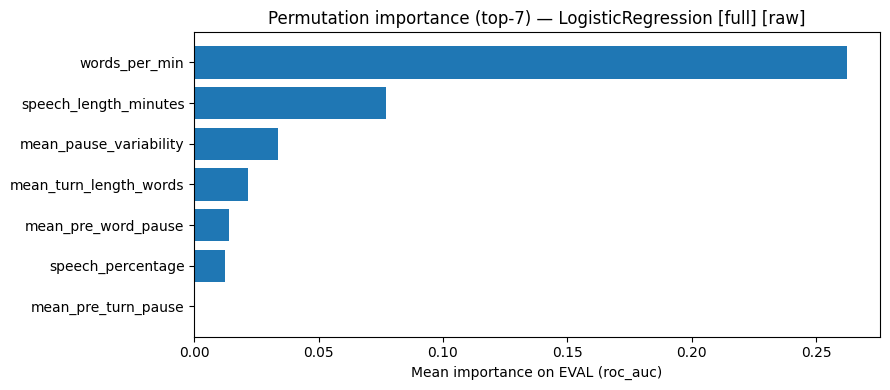


=== LogisticRegression [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Selected cols: ['words_per_min', 'speech_length_minutes', 'mean_pre_word_pause', 'mean_turn_length_words', 'mean_pre_turn_pause']
Train+Dev CV AUC: 0.6322474299893656 +/- 0.06113414785788035

Classification report:
               precision    recall  f1-score   support

           0      0.920     0.657     0.767        35
           1      0.613     0.905     0.731        21

    accuracy                          0.750        56
   macro avg      0.766     0.781     0.749        56
weighted avg      0.805     0.750     0.753        56

Confusion matrix:
 [[23 12]
 [ 2 19]]

[LogisticRegression [selected(top=30,corr<0.9)]] Top-5 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
         words_per_min         0.273061        0.065039
 speech_length_minutes         0.088707        0.022651
m

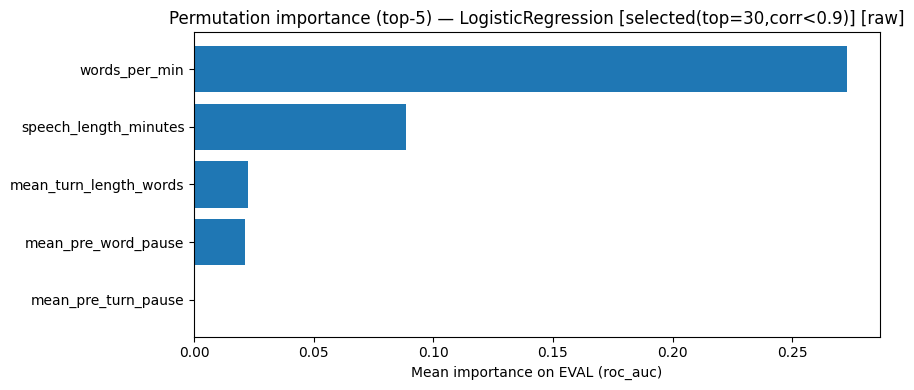


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Train+Dev CV AUC: 0.5651045728465084 +/- 0.11176139082953622

Classification report:
               precision    recall  f1-score   support

           0      0.895     0.486     0.630        35
           1      0.514     0.905     0.655        21

    accuracy                          0.643        56
   macro avg      0.704     0.695     0.642        56
weighted avg      0.752     0.643     0.639        56

Confusion matrix:
 [[17 18]
 [ 2 19]]

[SGDClassifier(log_loss) [full]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
mean_turn_length_words         0.184490        0.061355
         words_per_min         0.127755        0.029780
 speech_length_minutes         0.031973        0.027510
   mean_pre_word_pause         0.028571        0.037729
     speech_percentage         0.010204        0.02

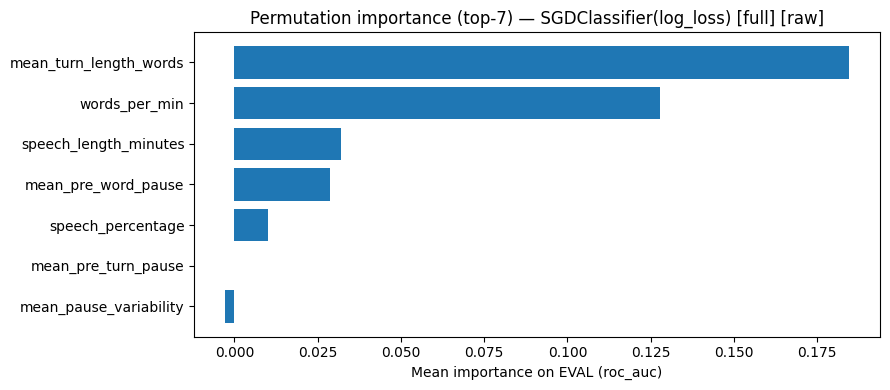


=== SGDClassifier(log_loss) [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Selected cols: ['words_per_min', 'mean_pre_word_pause', 'speech_length_minutes', 'mean_pre_turn_pause', 'mean_turn_length_words']
Train+Dev CV AUC: 0.6187262200165426 +/- 0.07764323281662674

Classification report:
               precision    recall  f1-score   support

           0      0.850     0.486     0.618        35
           1      0.500     0.857     0.632        21

    accuracy                          0.625        56
   macro avg      0.675     0.671     0.625        56
weighted avg      0.719     0.625     0.623        56

Confusion matrix:
 [[17 18]
 [ 3 18]]

[SGDClassifier(log_loss) [selected(top=30,corr<0.9)]] Top-5 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
         words_per_min         0.321088        0.066603
 speech_length_minutes         0.042449        

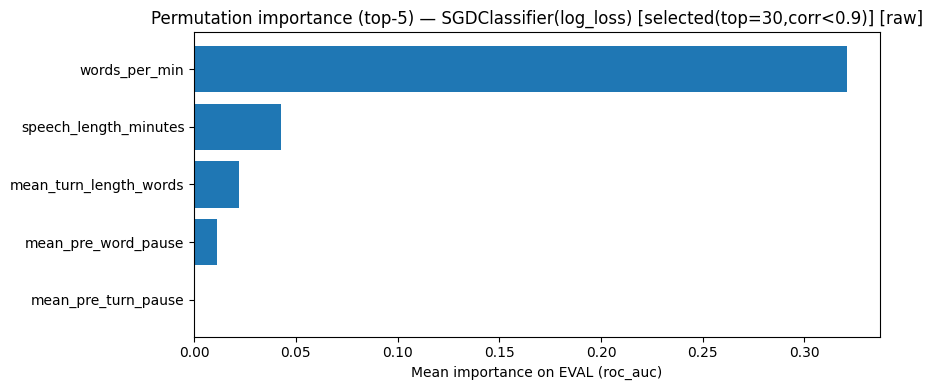

[WARN] DecisionTree[full]: very few unique predicted probabilities (5).

=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Best CV score: 0.625 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.6249562802788609 +/- 0.09414402722756476

Classification report:
               precision    recall  f1-score   support

           0      0.705     0.886     0.785        35
           1      0.667     0.381     0.485        21

    accuracy                          0.696        56
   macro avg      0.686     0.633     0.635        56
weighted avg      0.690     0.696     0.672        56

Confusion matrix:
 [[31  4]
 [13  8]]

[DecisionTree [full_tuned]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
         words_per_min         0.104490        0.063631
mean_pause_variability         0.081088     

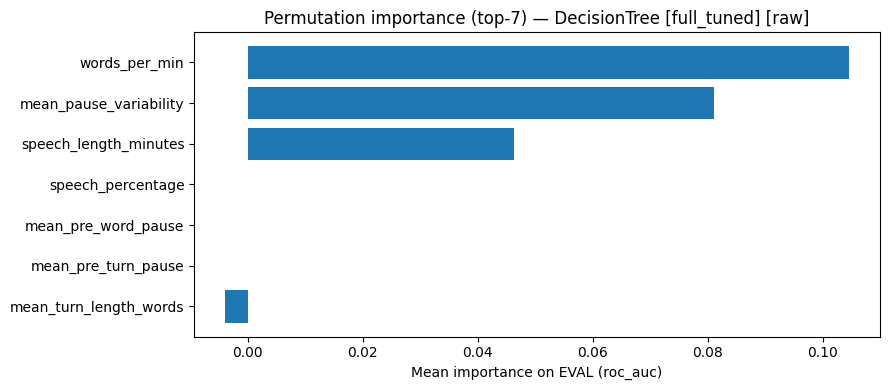

[WARN] DecisionTree[selected]: very few unique predicted probabilities (5).

=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Selected cols: ['speech_percentage', 'words_per_min', 'mean_pause_variability', 'speech_length_minutes', 'mean_pre_turn_pause', 'mean_turn_length_words']
Best CV score: 0.6392 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.6392419945645752 +/- 0.09195751047200018

Classification report:
               precision    recall  f1-score   support

           0      0.705     0.886     0.785        35
           1      0.667     0.381     0.485        21

    accuracy                          0.696        56
   macro avg      0.686     0.633     0.635        56
weighted avg      0.690     0.696     0.672        56

Confusion matrix:
 [[31  4]
 [13  8]]

[DecisionTree [selected_tuned]] Top-6 permutation importances (roc_

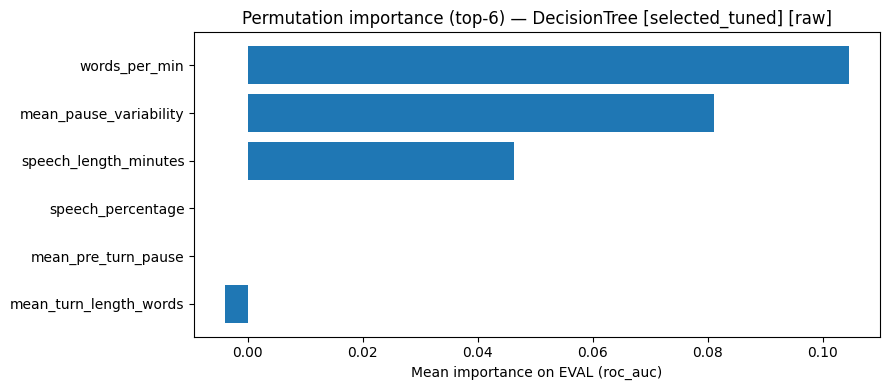


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Best CV score: 0.6125 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV AUC: 0.6124932057190122 +/- 0.05906992310943284

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.629     0.647        35
           1      0.435     0.476     0.455        21

    accuracy                          0.571        56
   macro avg      0.551     0.552     0.551        56
weighted avg      0.580     0.571     0.575        56

Confusion matrix:
 [[22 13]
 [11 10]]

[RandomForest [full_tuned]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
mean_turn_length_words         0.091429        0.030391
         words_per_min         0.053

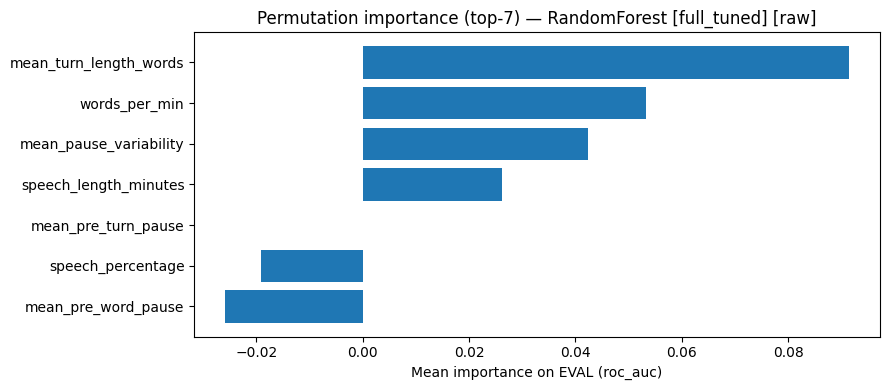


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Selected cols: ['words_per_min', 'speech_length_minutes', 'mean_pre_turn_pause', 'speech_percentage', 'mean_pause_variability', 'mean_turn_length_words']
Best CV score: 0.6118 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV AUC: 0.6117676946709205 +/- 0.05985226412273674

Classification report:
               precision    recall  f1-score   support

           0      0.688     0.629     0.657        35
           1      0.458     0.524     0.489        21

    accuracy                          0.589        56
   macro avg      0.573     0.576     0.573        56
weighted avg      0.602     0.589     0.594        56

Confusion matrix:
 [[22 13]
 [10 11]]

[RandomForest [selected_tuned]] Top-6 permutation importances (

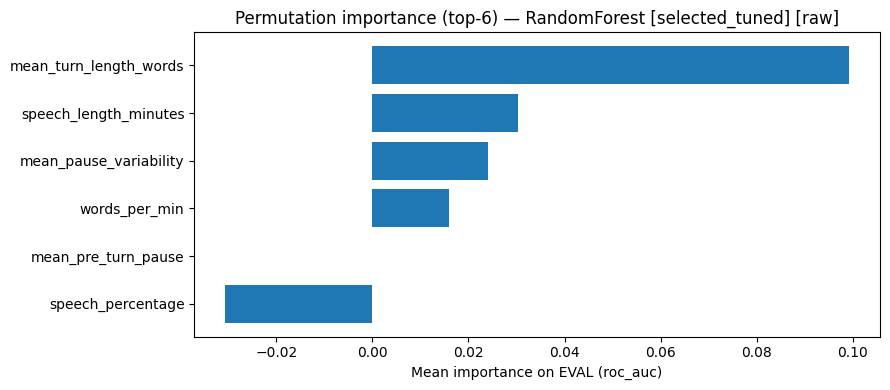


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Best CV score: 0.6308 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV AUC: 0.6307639135058489 +/- 0.06067681532082643

Classification report:
               precision    recall  f1-score   support

           0      0.731     0.543     0.623        35
           1      0.467     0.667     0.549        21

    accuracy                          0.589        56
   macro avg      0.599     0.605     0.586        56
weighted avg      0.632     0.589     0.595        56

Confusion matrix:
 [[19 16]
 [ 7 14]]

[XGBoost [full_tuned]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
mean_turn_length_words         0.115782        0.035425
mean_pause_variability 

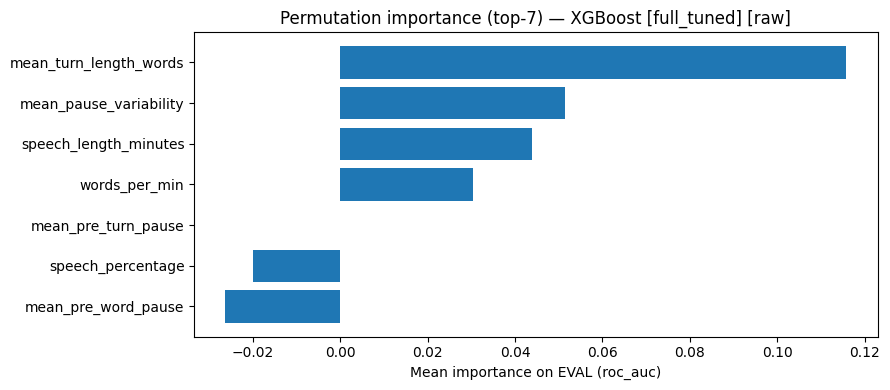


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv) ===
Selected cols: ['words_per_min', 'speech_percentage', 'speech_length_minutes', 'mean_pre_turn_pause', 'mean_pause_variability', 'mean_turn_length_words']
Best CV score: 0.6342 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV AUC: 0.6341675528772303 +/- 0.07420037697048651

Classification report:
               precision    recall  f1-score   support

           0      0.760     0.543     0.633        35
           1      0.484     0.714     0.577        21

    accuracy                          0.607        56
   macro avg      0.622     0.629     0.605        56
weighted avg      0.656     0.607     0.612        56

Confusion matrix:
 [[19 16]
 [ 6 15]]

[XGBoost [selected_tuned]] Top-6 permutation i

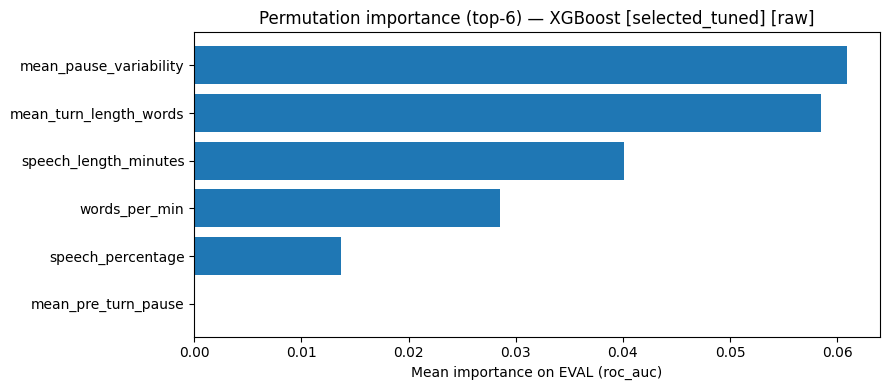


=== Summary metrics on TEST ===
    target                   model                   variant  tuned  cv_best_score  cv_auc_mean  cv_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                                           selected_cols
PTSD_label      LogisticRegression                      full  False            NaN       0.6265      0.0591                                                                                                                                                                                           219      56               7                  NaN    0.6964    0.6963 0.5828 0.8020        0.7381   0.8027  0.6721  0.9143 

In [8]:
res_b0_ptsd = run_models_pipeline_more_models_tuned_rocauc("/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_eng_test_small.csv", target_col="PTSD_label")

In [9]:
res_b0_ptsd

,target,model,variant,tuned,cv_best_score,cv_auc_mean,cv_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.626537,0.059100,,219,56,...,0.696332,0.582766,0.801993,0.738095,0.802721,0.672075,0.914320,0.702543,0.215459,
1,PTSD_label,LogisticRegression,"selected(top=30,corr<0.9)",False,NaN,0.632247,0.061134,,219,56,...,0.748718,0.630938,0.854167,0.780952,0.809524,0.684354,0.919728,0.712598,0.212867,"words_per_min,speech_length_minutes,mean_pre_w..."
2,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.565105,0.111761,,219,56,...,0.642401,0.517673,0.750000,0.695238,0.744218,0.597279,0.870748,0.663706,0.317011,
3,PTSD_label,SGDClassifier(log_loss),"selected(top=30,corr<0.9)",False,NaN,0.618726,0.077643,,219,56,...,0.624880,0.500000,0.732057,0.671429,0.778231,0.635374,0.903401,0.718880,0.246121,"words_per_min,mean_pre_word_pause,speech_lengt..."
4,PTSD_label,DecisionTree,full_tuned,True,0.624956,0.624956,0.094144,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.634829,0.499106,0.763713,0.633333,0.693878,0.568707,0.811582,0.517857,0.219296,
5,PTSD_label,DecisionTree,selected_tuned,True,0.639242,0.639242,0.091958,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.634829,0.499106,0.763713,0.633333,0.693878,0.568707,0.811582,0.517857,0.219296,"speech_percentage,words_per_min,mean_pause_var..."
6,PTSD_label,RandomForest,full_tuned,True,0.612493,0.612493,0.059070,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.550802,0.416667,0.684245,0.552381,0.600000,0.448946,0.746939,0.476692,0.241372,
7,PTSD_label,RandomForest,selected_tuned,True,0.611768,0.611768,0.059852,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.572803,0.441980,0.704875,0.576190,0.629932,0.480272,0.775510,0.475723,0.237096,"words_per_min,speech_length_minutes,mean_pre_t..."
8,PTSD_label,XGBoost,full_tuned,True,0.630764,0.630764,0.060677,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",219,56,...,0.585985,0.458065,0.710968,0.604762,0.600000,0.443537,0.738844,0.448431,0.251375,
9,PTSD_label,XGBoost,selected_tuned,True,0.634168,0.634168,0.074200,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",219,56,...,0.605128,0.464286,0.729990,0.628571,0.624490,0.473469,0.763299,0.458660,0.247060,"words_per_min,speech_percentage,speech_length_..."



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (7): ['Depression_label', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 20) | X_test shape: (56, 20)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Train+Dev CV AUC: 0.6997896726928985 +/- 0.06566184599011486

Classification report:
               precision    recall  f1-score   support

           0      0.793     0.657     0.719        35
           1      0.556     0.714     0.625        21

    accuracy                          0.679        56
   macro avg      0.674     0.686     0.672        56
weighted avg      0.704     0.679     0.684        56

Confusion matrix:
 [[23 12]
 [ 6 15]]

[LogisticRegression [full]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_

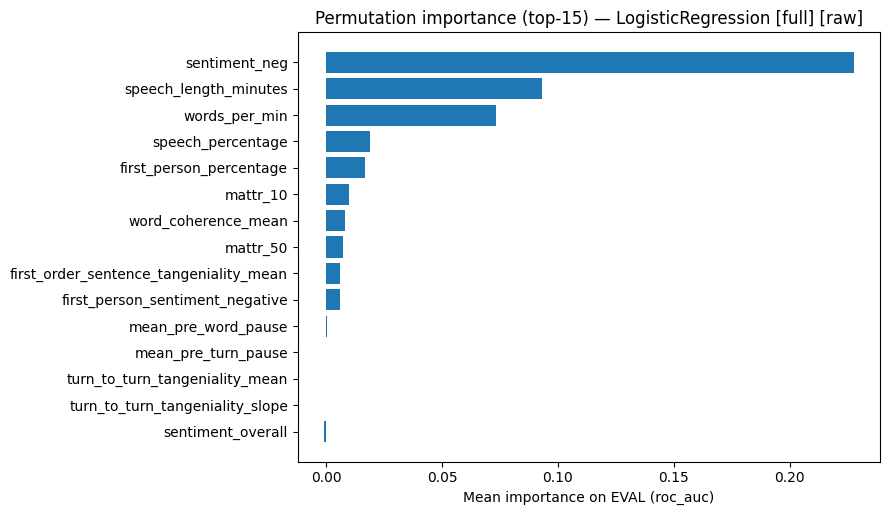


=== LogisticRegression [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Selected cols: ['sentiment_neg', 'speech_length_minutes', 'sentiment_pos', 'first_person_percentage', 'syllables_per_min', 'mean_pause_variability', 'words_per_min', 'first_order_sentence_tangeniality_mean', 'sentiment_overall', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'mattr_10', 'mattr_50', 'semantic_perplexity_mean', 'first_person_sentiment_negative', 'mean_turn_length_words']
Train+Dev CV AUC: 0.704192366773012 +/- 0.06885865316366034

Classification report:
               precision    recall  f1-score   support

           0      0.793     0.657     0.719        35
           1      0.556     0.714     0.625        21

    accuracy                          0.679        56
   macro avg      0.674     0.686     0.672        56
weighted avg      0.704     0.679     0.684        56

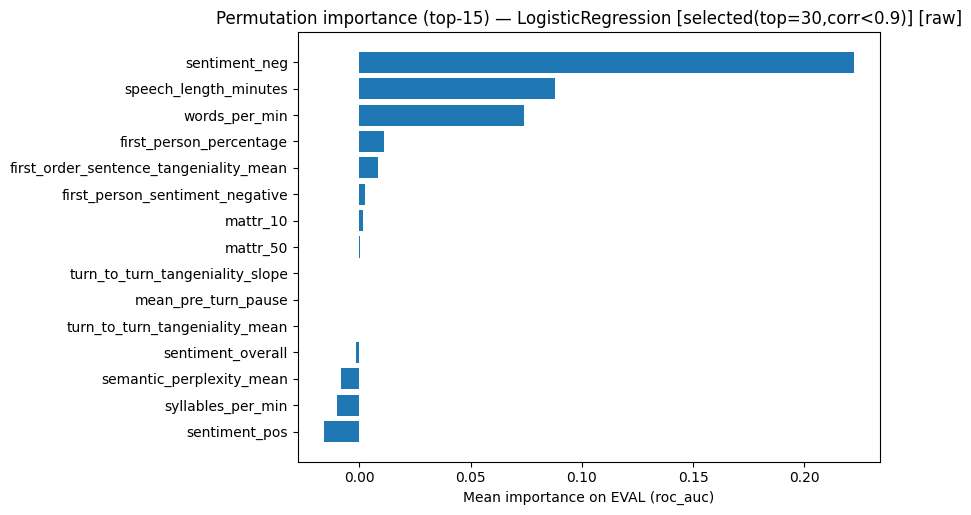


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Train+Dev CV AUC: 0.6696703296703297 +/- 0.07365022805042502

Classification report:
               precision    recall  f1-score   support

           0      0.703     0.743     0.722        35
           1      0.526     0.476     0.500        21

    accuracy                          0.643        56
   macro avg      0.615     0.610     0.611        56
weighted avg      0.637     0.643     0.639        56

Confusion matrix:
 [[26  9]
 [11 10]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std
                         sentiment_neg         0.130748        0.034136
                         words_per_min         0.089660        0.023663
                 speech_length_minutes         0.044626        0.010013
first_order_sentence_tangeniality_mean  

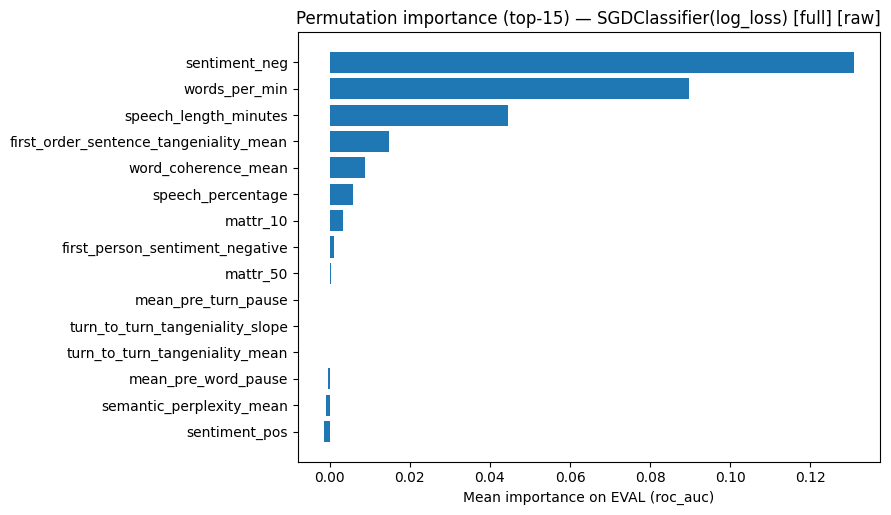


=== SGDClassifier(log_loss) [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Selected cols: ['sentiment_neg', 'speech_length_minutes', 'words_per_min', 'syllables_per_min', 'mean_pause_variability', 'sentiment_pos', 'first_person_percentage', 'mattr_10', 'sentiment_overall', 'first_order_sentence_tangeniality_mean', 'mattr_50', 'turn_to_turn_tangeniality_slope', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'semantic_perplexity_mean', 'mean_turn_length_words', 'first_person_sentiment_negative']
Train+Dev CV AUC: 0.6750053172633816 +/- 0.014231701449941538

Classification report:
               precision    recall  f1-score   support

           0      0.625     0.286     0.392        35
           1      0.375     0.714     0.492        21

    accuracy                          0.446        56
   macro avg      0.500     0.500     0.442        56
weighted avg      0.531     0.446     0.430   

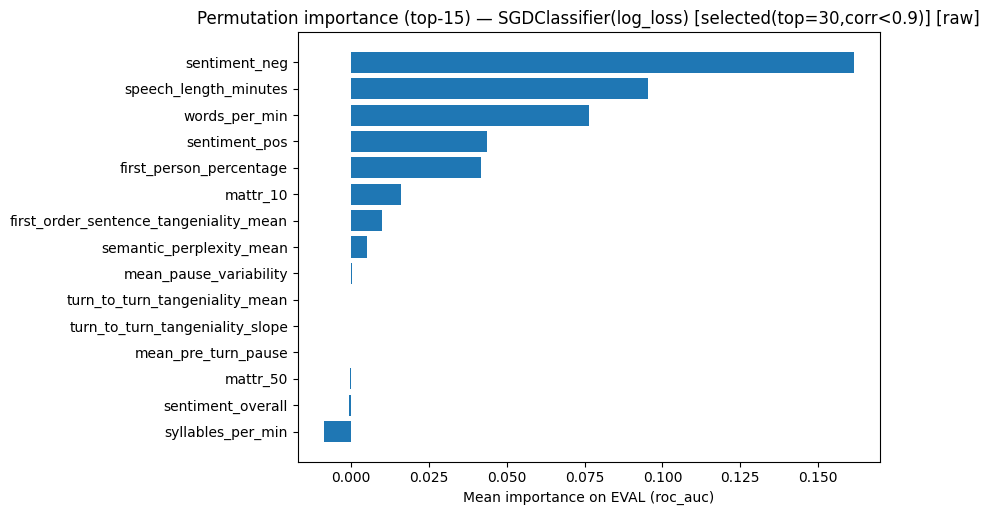


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Best CV score: 0.5835 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.5835082122178897 +/- 0.03964881747928314

Classification report:
               precision    recall  f1-score   support

           0      0.643     0.514     0.571        35
           1      0.393     0.524     0.449        21

    accuracy                          0.518        56
   macro avg      0.518     0.519     0.510        56
weighted avg      0.549     0.518     0.526        56

Confusion matrix:
 [[18 17]
 [10 11]]

[DecisionTree [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                 feature  importance_mean  importance_std
       sentiment_overall         0.021905        0.052200
           words_per_min         0.021565        0.029696
           sentiment_neg         0.014966        0

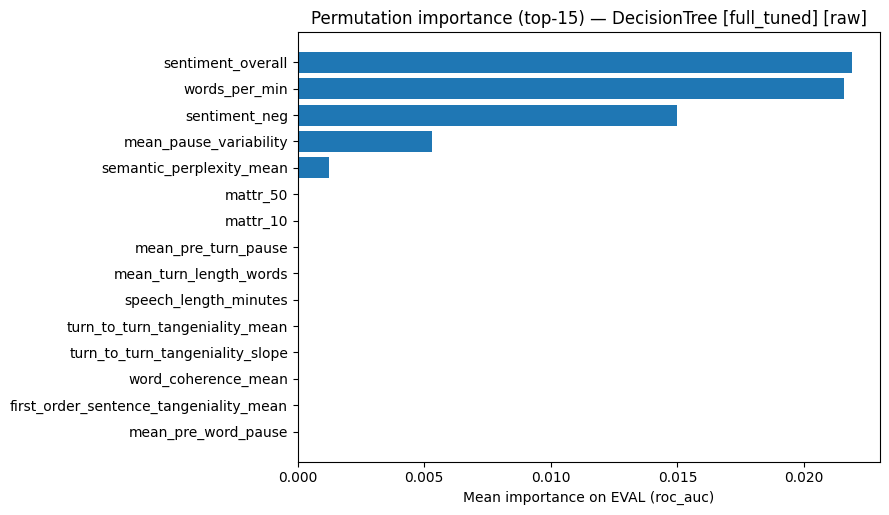


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Selected cols: ['sentiment_neg', 'speech_length_minutes', 'first_person_sentiment_negative', 'words_per_min', 'first_order_sentence_tangeniality_mean', 'mattr_10', 'semantic_perplexity_mean', 'sentiment_pos', 'mean_pause_variability', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'syllables_per_min', 'first_person_percentage', 'mattr_50', 'speech_percentage', 'sentiment_overall', 'mean_turn_length_words']
Best CV score: 0.591 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5}
Train+Dev CV AUC: 0.5909606522509747 +/- 0.05701442167088575

Classification report:
               precision    recall  f1-score   support

           0      0.600     0.514     0.554        35
           1      0.346     0.429     0.383        21

    accuracy                          0.482

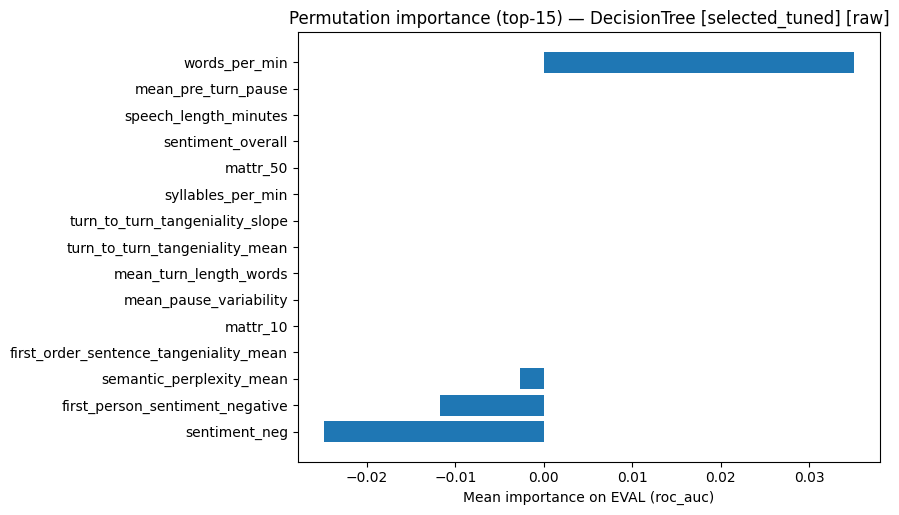


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Best CV score: 0.7078 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV AUC: 0.7077714758359919 +/- 0.032326604870814846

Classification report:
               precision    recall  f1-score   support

           0      0.697     0.657     0.676        35
           1      0.478     0.524     0.500        21

    accuracy                          0.607        56
   macro avg      0.588     0.590     0.588        56
weighted avg      0.615     0.607     0.610        56

Confusion matrix:
 [[23 12]
 [10 11]]

[RandomForest [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                        feature  importance_mean  importance_std
                  sentiment_neg         0.078639        0.043972
         mean_

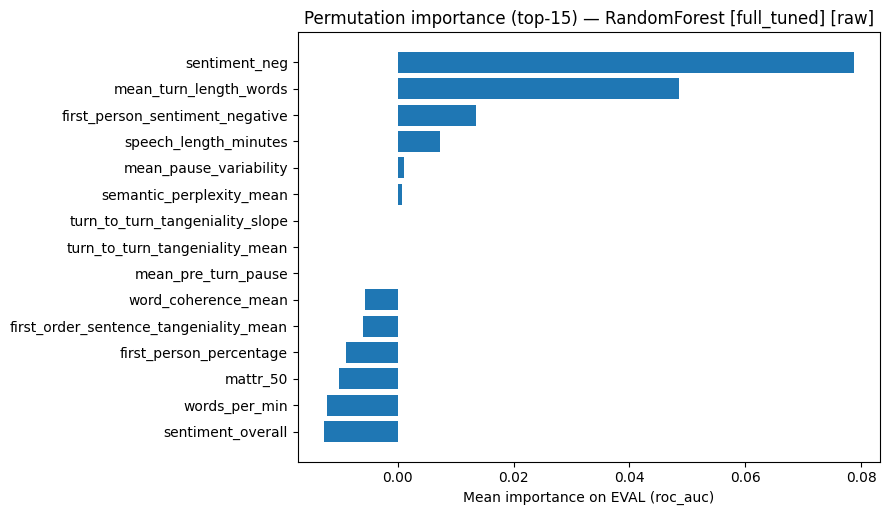


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Selected cols: ['sentiment_neg', 'sentiment_overall', 'speech_percentage', 'sentiment_pos', 'word_coherence_mean', 'speech_length_minutes', 'first_person_sentiment_negative', 'words_per_min', 'first_person_percentage', 'mean_turn_length_words', 'mattr_10', 'mattr_50', 'turn_to_turn_tangeniality_slope', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'syllables_per_min', 'semantic_perplexity_mean']
Best CV score: 0.7089 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV AUC: 0.708864468864469 +/- 0.05036613724091994

Classification report:
               precision    recall  f1-score   support

           0      0.730     0.771     0.750        35
           1      0.579     0.524     0.550        21

    accu

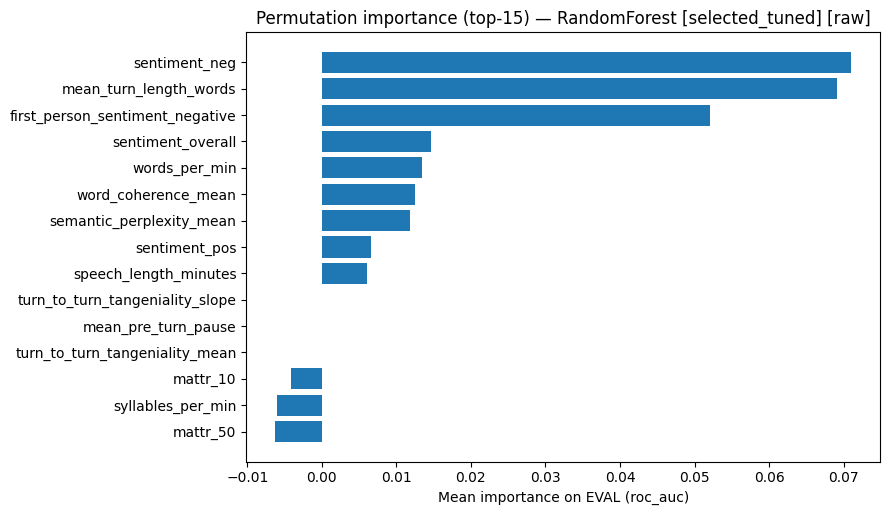


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Best CV score: 0.6729 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV AUC: 0.6729374926149121 +/- 0.04608500036337622

Classification report:
               precision    recall  f1-score   support

           0      0.700     0.600     0.646        35
           1      0.462     0.571     0.511        21

    accuracy                          0.589        56
   macro avg      0.581     0.586     0.578        56
weighted avg      0.611     0.589     0.595        56

Confusion matrix:
 [[21 14]
 [ 9 12]]

[XGBoost [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                        feature  importance_mean  importance_std
                  sentiment_neg         0.057687        0.035276
  

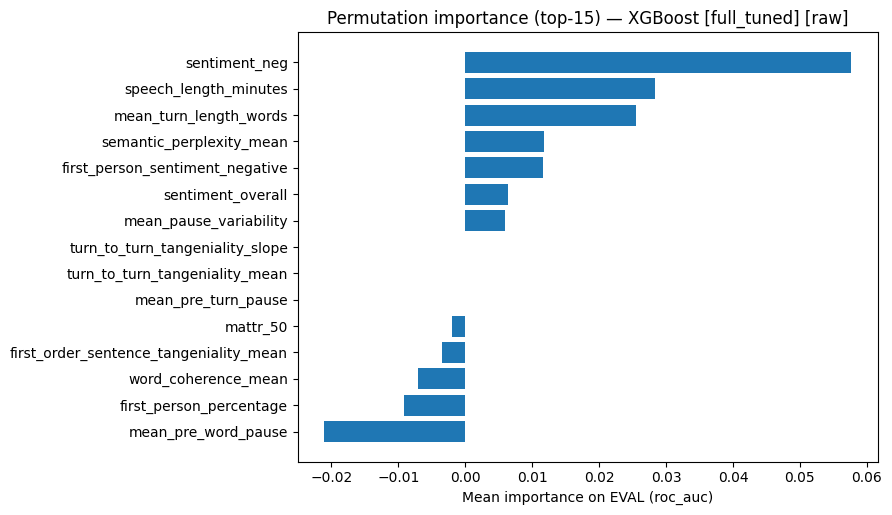


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv) ===
Selected cols: ['sentiment_neg', 'sentiment_overall', 'speech_length_minutes', 'first_person_sentiment_negative', 'semantic_perplexity_mean', 'speech_percentage', 'sentiment_pos', 'words_per_min', 'first_order_sentence_tangeniality_mean', 'mattr_10', 'first_person_percentage', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'mean_turn_length_words', 'syllables_per_min', 'mean_pause_variability', 'mattr_50']
Best CV score: 0.6681 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Train+Dev CV AUC: 0.6681235968332744 +/- 0.03532082150592409

Classification report:
               precision    recall  f1-score   support

           0      0.710     0.629     0.667        35


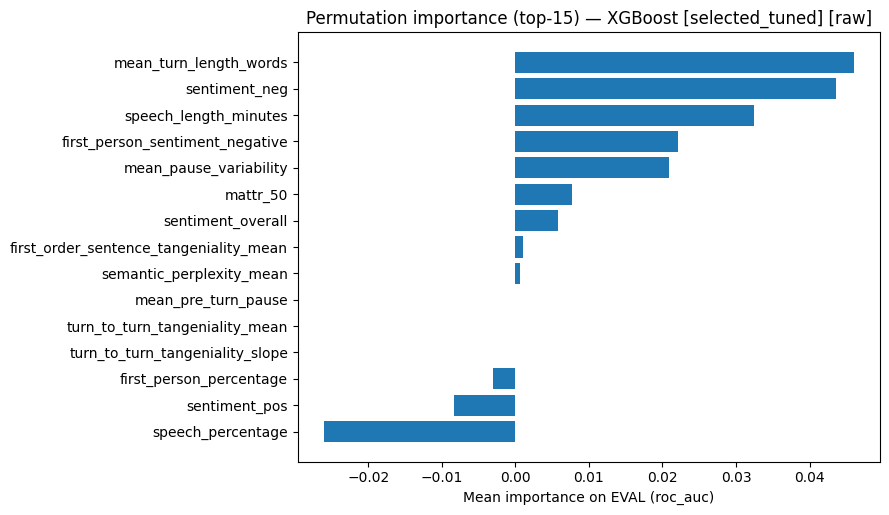


=== Summary metrics on TEST ===
    target                   model                   variant  tuned  cv_best_score  cv_auc_mean  cv_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                                                                                                                                                                                                                                                                                                                    selected_cols
PTSD_label      LogisticRegression                      full  False            NaN       0.6998      0.0657                                            

In [10]:
res_b0_l_ptsd = run_models_pipeline_more_models_tuned_rocauc("/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_eng_small.csv", target_col="PTSD_label")

In [11]:
res_b0_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_auc_mean,cv_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.699790,0.065662,,219,56,...,0.671875,0.549984,0.795688,0.685714,0.727891,0.582313,0.862585,0.689635,0.221714,
1,PTSD_label,LogisticRegression,"selected(top=30,corr<0.9)",False,NaN,0.704192,0.068859,,219,56,...,0.671875,0.549984,0.795688,0.685714,0.723810,0.575510,0.857143,0.684739,0.220872,"sentiment_neg,speech_length_minutes,sentiment_..."
2,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.669670,0.073650,,219,56,...,0.611111,0.480591,0.741765,0.609524,0.647619,0.482993,0.810884,0.679997,0.342542,
3,PTSD_label,SGDClassifier(log_loss),"selected(top=30,corr<0.9)",False,NaN,0.675005,0.014232,,219,56,...,0.441980,0.313548,0.569231,0.500000,0.517007,0.352381,0.692517,0.425484,0.538163,"sentiment_neg,speech_length_minutes,words_per_..."
4,PTSD_label,DecisionTree,full_tuned,True,0.583508,0.583508,0.039649,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.510204,0.373201,0.641035,0.519048,0.508163,0.344847,0.678929,0.434200,0.392153,
5,PTSD_label,DecisionTree,selected_tuned,True,0.590961,0.590961,0.057014,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.468412,0.339075,0.603640,0.471429,0.431973,0.270051,0.595238,0.383797,0.425884,"sentiment_neg,speech_length_minutes,first_pers..."
6,PTSD_label,RandomForest,full_tuned,True,0.707771,0.707771,0.032327,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.588235,0.455135,0.716886,0.590476,0.621769,0.457143,0.772823,0.555380,0.227845,
7,PTSD_label,RandomForest,selected_tuned,True,0.708864,0.708864,0.050366,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.650000,0.518750,0.775401,0.647619,0.644898,0.487041,0.795952,0.580629,0.225461,"sentiment_neg,sentiment_overall,speech_percent..."
8,PTSD_label,XGBoost,full_tuned,True,0.672937,0.672937,0.046085,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",219,56,...,0.578396,0.438503,0.708333,0.585714,0.582313,0.404048,0.751088,0.512426,0.249549,
9,PTSD_label,XGBoost,selected_tuned,True,0.668124,0.668124,0.035321,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",219,56,...,0.594203,0.461277,0.727781,0.600000,0.625850,0.463912,0.780986,0.551583,0.238578,"sentiment_neg,sentiment_overall,speech_length_..."


# Training Gemma, ukr, small feature set

## L 

In [12]:
detailed_labels_path = "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/detailed_lables.csv"
data_dir = "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/result_oppenwillis_ukr_norm_gemma"

# --- L ---
df_l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=L_TURNS,
    summary_cols=L_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,
)

L_OUT_COLS = [c for c in df_l.columns if c in SPINE_COLS] + \
            [c for c in df_l.columns if (c in L_TURNS or c.endswith("_turns"))] + \
            [c for c in df_l.columns if (c in L_SUMMARY or c.endswith("_summary"))]

df_l_out = df_l[_unique_preserve_order(L_OUT_COLS)].copy()
df_l_out.to_csv(
    "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv",
    index=False
)
df_l_out.columns

Index(['Participant', 'PTSD_severity', 'gender', 'age', 'Depression_label',
       'PTSD_label', 'split', 'syllables_per_min', 'sentiment_pos',
       'sentiment_neg', 'mattr_50', 'first_person_percentage',
       'first_person_sentiment_negative', 'mattr_10', 'sentiment_overall',
       'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope',
       'word_coherence_mean', 'first_order_sentence_tangeniality_mean',
       'semantic_perplexity_mean'],
      dtype='object')

### b0

In [13]:

# --- B0 ---
df_b0 = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=B0_TURNS,
    summary_cols=B0_SUMMARY,
    turns_agg="mean",
    resolve_name_collisions=True,  # keeps both turns+summary if same name exists
)

b0_feature_cols = _unique_preserve_order(
    [c for c in df_b0.columns if c not in df_b0.columns.difference(df_b0.columns)]  # noop, keep below
)
# safer: explicitly compute expected output cols by checking presence
B0_OUT_COLS = [c for c in df_b0.columns if c in SPINE_COLS] + \
             [c for c in df_b0.columns if (c in B0_TURNS or c.endswith("_turns"))] + \
             [c for c in df_b0.columns if (c in B0_SUMMARY or c.endswith("_summary"))]

df_b0_out = df_b0[_unique_preserve_order(B0_OUT_COLS)].copy()
df_b0_out.to_csv(
    "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv",
    index=False
)
df_b0_out.columns

Index(['Participant', 'PTSD_severity', 'gender', 'age', 'Depression_label',
       'PTSD_label', 'split', 'words_per_min', 'speech_percentage',
       'mean_pre_word_pause', 'mean_pause_variability', 'mean_pre_turn_pause',
       'mean_turn_length_words', 'speech_length_minutes'],
      dtype='object')

### b0+L

In [14]:
# --- B0 + L ---
df_b0l = merge_turns_and_summary_featureblock(
    detailed_labels_path=detailed_labels_path,
    data_dir=data_dir,
    participant_col="Participant",
    turns_cols=_union(B0_TURNS, L_TURNS),
    summary_cols=_union(B0_SUMMARY, L_SUMMARY),
    turns_agg="mean",
    resolve_name_collisions=True,
)

B0L_OUT_COLS = [c for c in df_b0l.columns if c in SPINE_COLS] + \
              [c for c in df_b0l.columns if (c in _union(B0_TURNS, L_TURNS) or c.endswith("_turns"))] + \
              [c for c in df_b0l.columns if (c in _union(B0_SUMMARY, L_SUMMARY) or c.endswith("_summary"))]

df_b0l_out = df_b0l[_unique_preserve_order(B0L_OUT_COLS)].copy()
df_b0l_out.to_csv(
    "/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv",
    index=False
)
df_b0l_out.columns

Index(['Participant', 'PTSD_severity', 'gender', 'age', 'Depression_label',
       'PTSD_label', 'split', 'words_per_min', 'speech_percentage',
       'syllables_per_min', 'sentiment_pos', 'sentiment_neg', 'mattr_50',
       'first_person_percentage', 'first_person_sentiment_negative',
       'mattr_10', 'sentiment_overall', 'mean_pre_word_pause',
       'mean_pause_variability', 'mean_pre_turn_pause',
       'mean_turn_length_words', 'speech_length_minutes',
       'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope',
       'word_coherence_mean', 'first_order_sentence_tangeniality_mean',
       'semantic_perplexity_mean'],
      dtype='object')

## test result, target - PTSD


[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (7): ['Depression_label', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 13) | X_test shape: (56, 13)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Train+Dev CV AUC: 0.6146661940210327 +/- 0.07906173304020385

Classification report:
               precision    recall  f1-score   support

           0      0.706     0.686     0.696        35
           1      0.500     0.524     0.512        21

    accuracy                          0.625        56
   macro avg      0.603     0.605     0.604        56
weighted avg      0.629     0.625     0.627        56

Confusion matrix:
 [[24 11]
 [10 11]]

[LogisticRegression [full]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std


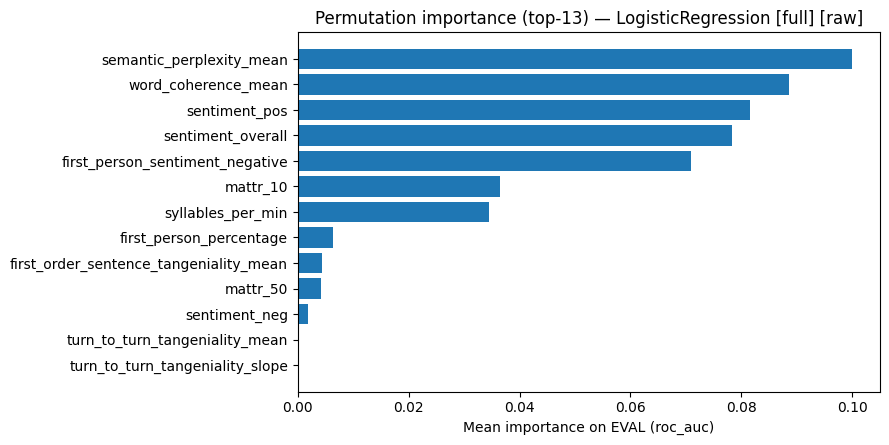


=== LogisticRegression [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Selected cols: ['word_coherence_mean', 'mattr_10', 'sentiment_overall', 'sentiment_pos', 'first_person_sentiment_negative', 'syllables_per_min', 'semantic_perplexity_mean', 'sentiment_neg', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'mattr_50', 'first_person_percentage']
Train+Dev CV AUC: 0.6189318208673047 +/- 0.08275050765216425

Classification report:
               precision    recall  f1-score   support

           0      0.706     0.686     0.696        35
           1      0.500     0.524     0.512        21

    accuracy                          0.625        56
   macro avg      0.603     0.605     0.604        56
weighted avg      0.629     0.625     0.627        56

Confusion matrix:
 [[24 11]
 [10 11]]

[LogisticRegression [selected(top=30,corr<0.9)]] Top-10 permutation importances (roc_auc, raw):
  

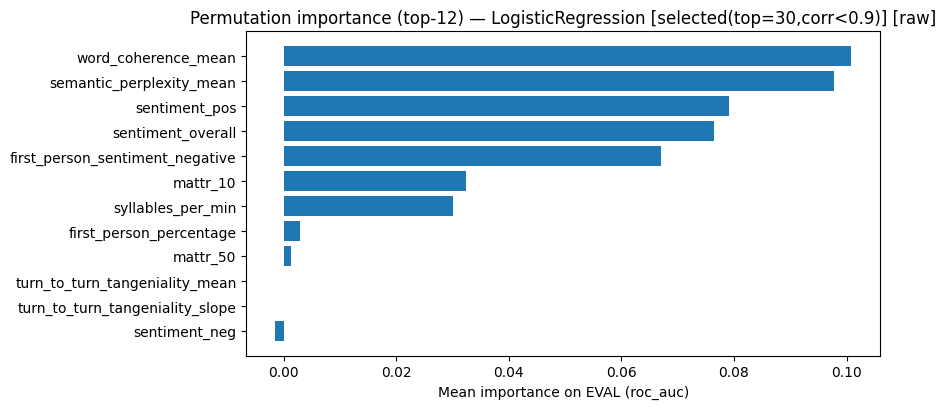


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Train+Dev CV AUC: 0.5170282405766278 +/- 0.06949323563089703

Classification report:
               precision    recall  f1-score   support

           0      0.714     0.571     0.635        35
           1      0.464     0.619     0.531        21

    accuracy                          0.589        56
   macro avg      0.589     0.595     0.583        56
weighted avg      0.621     0.589     0.596        56

Confusion matrix:
 [[20 15]
 [ 8 13]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std
                     sentiment_overall         0.045578        0.023661
                         sentiment_pos         0.041497        0.065156
                   word_coherence_mean         0.030612        0.037425
       first_person_sentiment_negative      

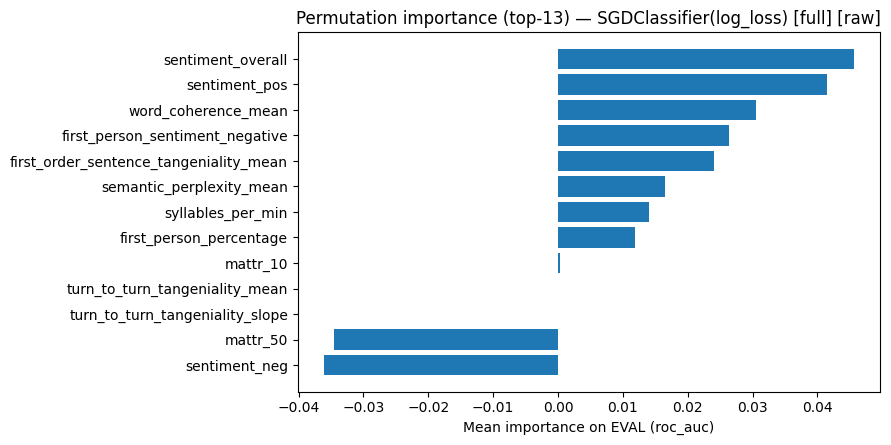


=== SGDClassifier(log_loss) [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Selected cols: ['word_coherence_mean', 'sentiment_pos', 'mattr_10', 'sentiment_overall', 'syllables_per_min', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'first_person_sentiment_negative', 'semantic_perplexity_mean', 'sentiment_neg', 'mattr_50', 'first_person_percentage']
Train+Dev CV AUC: 0.5325168380007089 +/- 0.11468349002621006

Classification report:
               precision    recall  f1-score   support

           0      0.731     0.543     0.623        35
           1      0.467     0.667     0.549        21

    accuracy                          0.589        56
   macro avg      0.599     0.605     0.586        56
weighted avg      0.632     0.589     0.595        56

Confusion matrix:
 [[19 16]
 [ 7 14]]

[SGDClassifier(log_loss) [selected(top=30,corr<0.9)]] Top-10 permutation importances (roc_auc

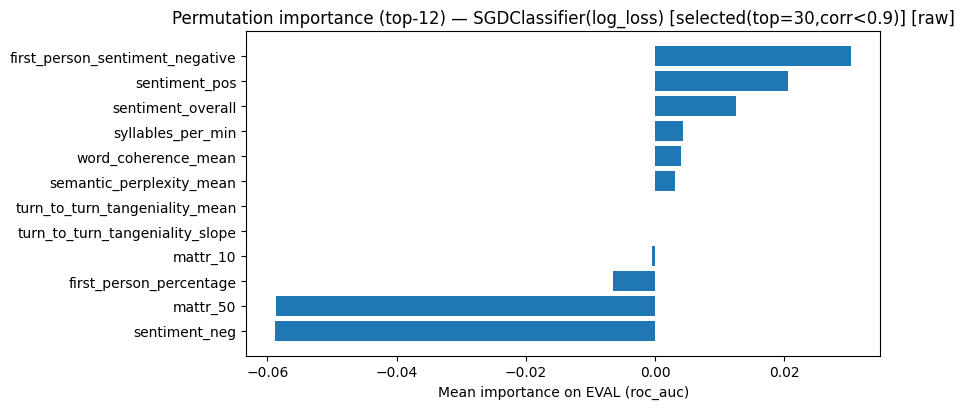


=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Best CV score: 0.5021 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.5020560085076214 +/- 0.0923077016855814

Classification report:
               precision    recall  f1-score   support

           0      0.621     0.514     0.562        35
           1      0.370     0.476     0.417        21

    accuracy                          0.500        56
   macro avg      0.496     0.495     0.490        56
weighted avg      0.527     0.500     0.508        56

Confusion matrix:
 [[18 17]
 [11 10]]

[DecisionTree [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                        feature  importance_mean  importance_std
              sentiment_overall         0.037007        0.039210
first_person_sentiment_negative         0.012789        0.065329
                  sentiment_neg   

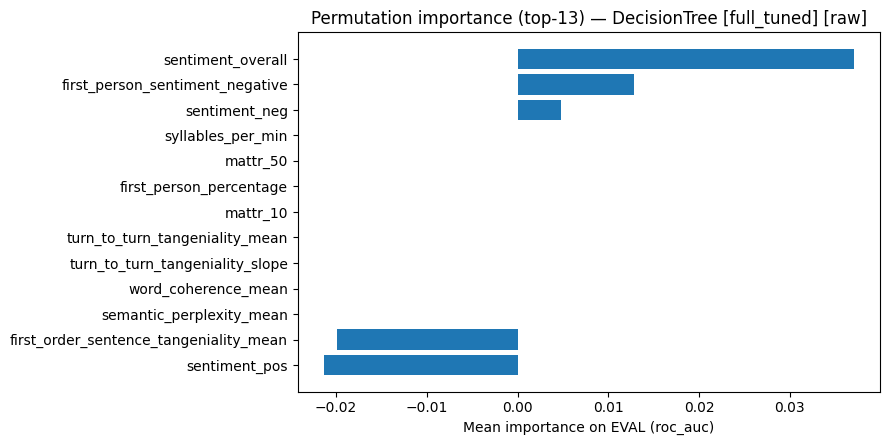


=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Selected cols: ['first_order_sentence_tangeniality_mean', 'sentiment_overall', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'sentiment_neg', 'first_person_sentiment_negative', 'semantic_perplexity_mean', 'syllables_per_min', 'mattr_10', 'first_person_percentage', 'sentiment_pos', 'mattr_50']
Best CV score: 0.5056 Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.5055813541297413 +/- 0.06528228842229085

Classification report:
               precision    recall  f1-score   support

           0      0.621     0.514     0.562        35
           1      0.370     0.476     0.417        21

    accuracy                          0.500        56
   macro avg      0.496     0.495     0.490        56
weighted avg      0.527     0.500     0.508        56

Confusion matrix:
 [[

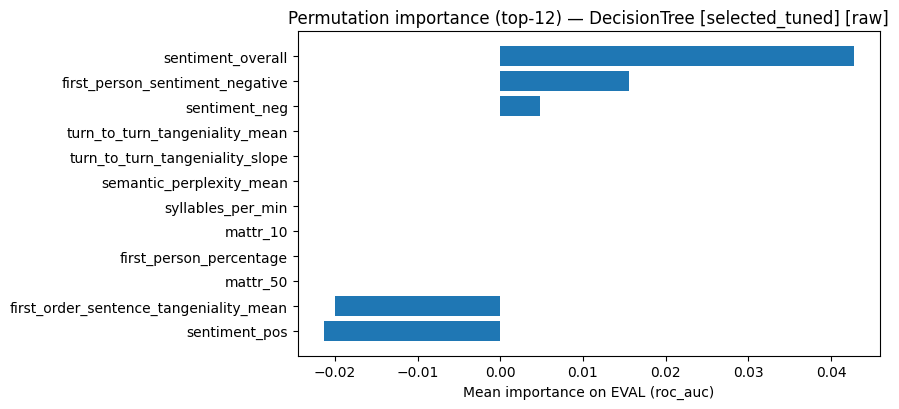


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Best CV score: 0.5575 Best params: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV AUC: 0.5575150655795816 +/- 0.07866179886578602

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.857     0.750        35
           1      0.545     0.286     0.375        21

    accuracy                          0.643        56
   macro avg      0.606     0.571     0.562        56
weighted avg      0.621     0.643     0.609        56

Confusion matrix:
 [[30  5]
 [15  6]]

[RandomForest [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std
                     syllables_per_min         0.063129        0.021531
 

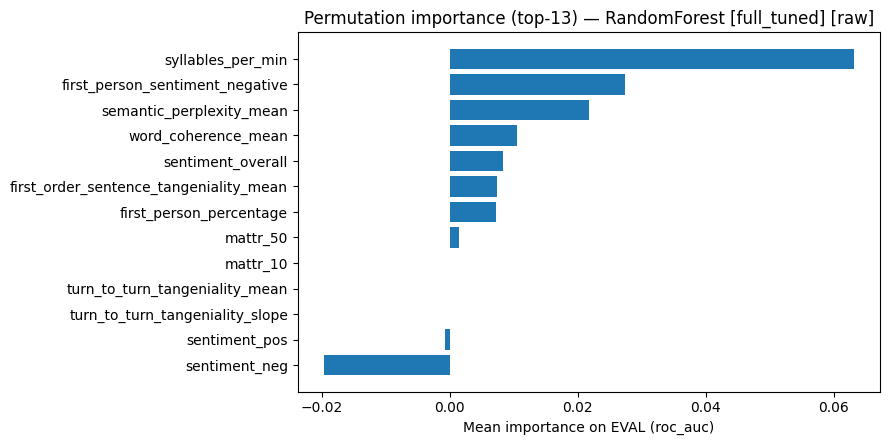


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Selected cols: ['first_order_sentence_tangeniality_mean', 'mattr_10', 'sentiment_pos', 'syllables_per_min', 'semantic_perplexity_mean', 'mattr_50', 'first_person_percentage', 'sentiment_overall', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'first_person_sentiment_negative', 'sentiment_neg']
Best CV score: 0.5547 Best params: {'clf__bootstrap': True, 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 500}
Train+Dev CV AUC: 0.5547181850407658 +/- 0.07303524308746728

Classification report:
               precision    recall  f1-score   support

           0      0.681     0.914     0.780        35
           1      0.667     0.286     0.400        21

    accuracy                          0.679        56
   macro avg      0.674     0.600     0.590       

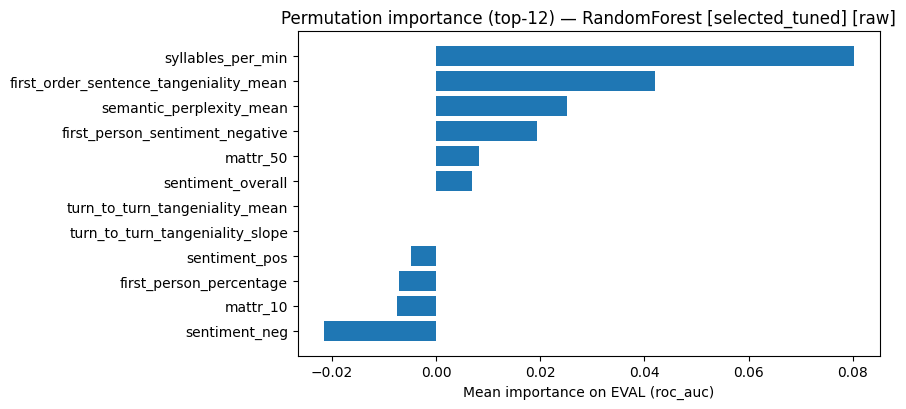


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Best CV score: 0.5291 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 500, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Train+Dev CV AUC: 0.5291315136476428 +/- 0.06075639916347005

Classification report:
               precision    recall  f1-score   support

           0      0.650     0.743     0.693        35
           1      0.438     0.333     0.378        21

    accuracy                          0.589        56
   macro avg      0.544     0.538     0.536        56
weighted avg      0.570     0.589     0.575        56

Confusion matrix:
 [[26  9]
 [14  7]]

[XGBoost [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std
                     syllables_per_min         0.068299        0

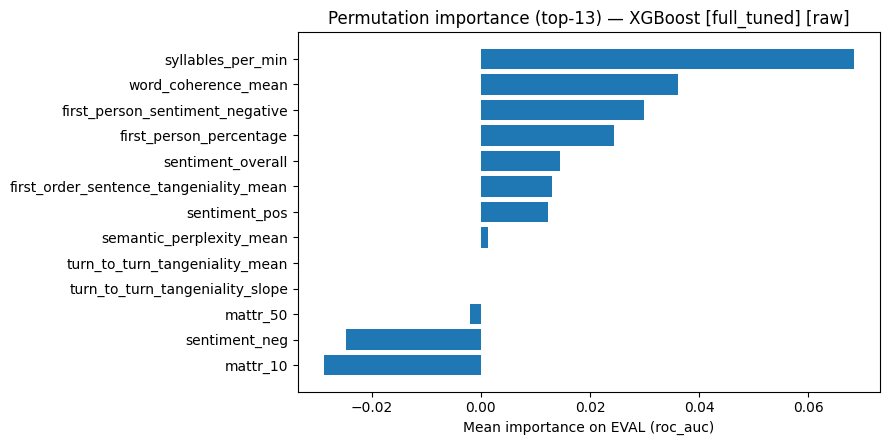


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv) ===
Selected cols: ['word_coherence_mean', 'sentiment_pos', 'mattr_10', 'first_person_sentiment_negative', 'mattr_50', 'semantic_perplexity_mean', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'sentiment_overall', 'sentiment_neg', 'first_person_percentage', 'syllables_per_min']
Best CV score: 0.5272 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 500, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Train+Dev CV AUC: 0.527159399740045 +/- 0.058470771737430226

Classification report:
               precision    recall  f1-score   support

           0      0.650     0.743     0.693        35
           1      0.438     0.333     0.378        21

    accuracy                          0.589        56
   macro avg      0.544     0.538     0.536        5

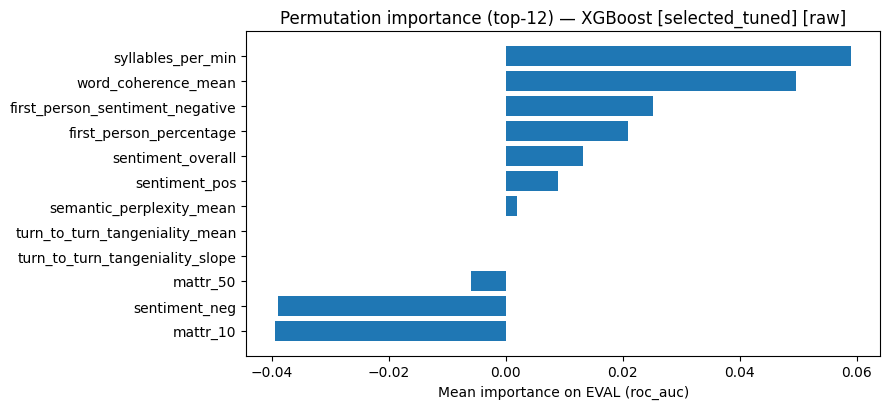


=== Summary metrics on TEST ===
    target                   model                   variant  tuned  cv_best_score  cv_auc_mean  cv_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                                                                                                                                                                                            selected_cols
PTSD_label      LogisticRegression                      full  False            NaN       0.6147      0.0791                                                                                                                                                                    

In [16]:
res_l_ptsd = run_models_pipeline_more_models_tuned_rocauc("/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_L_gemma_ukr_add_small.csv", target_col="PTSD_label")

In [17]:
res_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_auc_mean,cv_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.614666,0.079062,,219,56,...,0.603640,0.466667,0.727778,0.604762,0.692517,0.536020,0.828571,0.564567,0.224726,
1,PTSD_label,LogisticRegression,"selected(top=30,corr<0.9)",False,NaN,0.618932,0.082751,,219,56,...,0.603640,0.466667,0.727778,0.604762,0.689796,0.531871,0.827245,0.563752,0.224643,"word_coherence_mean,mattr_10,sentiment_overall..."
2,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.517028,0.069493,,219,56,...,0.582766,0.453125,0.708333,0.595238,0.552381,0.400000,0.702075,0.410993,0.392463,
3,PTSD_label,SGDClassifier(log_loss),"selected(top=30,corr<0.9)",False,NaN,0.532517,0.114683,,219,56,...,0.585985,0.453125,0.710968,0.604762,0.536054,0.386361,0.692517,0.386308,0.394378,"word_coherence_mean,sentiment_pos,mattr_10,sen..."
4,PTSD_label,DecisionTree,full_tuned,True,0.502056,0.502056,0.092308,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.489583,0.358429,0.619048,0.495238,0.512245,0.355085,0.667381,0.394235,0.308547,
5,PTSD_label,DecisionTree,selected_tuned,True,0.505581,0.505581,0.065282,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",219,56,...,0.489583,0.358429,0.619048,0.495238,0.517687,0.360527,0.674150,0.397500,0.308547,"first_order_sentence_tangeniality_mean,sentime..."
6,PTSD_label,RandomForest,full_tuned,True,0.557515,0.557515,0.078662,"{'clf__bootstrap': True, 'clf__max_depth': Non...",219,56,...,0.562500,0.428571,0.693750,0.571429,0.632653,0.461190,0.790510,0.614063,0.224203,
7,PTSD_label,RandomForest,selected_tuned,True,0.554718,0.554718,0.073035,"{'clf__bootstrap': True, 'clf__max_depth': 10,...",219,56,...,0.590244,0.449016,0.720752,0.600000,0.602721,0.427211,0.760544,0.590029,0.230465,"first_order_sentence_tangeniality_mean,mattr_1..."
8,PTSD_label,XGBoost,full_tuned,True,0.529132,0.529132,0.060756,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",219,56,...,0.535856,0.402443,0.657268,0.538095,0.583673,0.413605,0.745612,0.556613,0.274227,
9,PTSD_label,XGBoost,selected_tuned,True,0.527159,0.527159,0.058471,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",219,56,...,0.535856,0.397849,0.665613,0.538095,0.575510,0.404048,0.737415,0.565811,0.274858,"word_coherence_mean,sentiment_pos,mattr_10,fir..."



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (7): ['Depression_label', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 7) | X_test shape: (56, 7)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Train+Dev CV AUC: 0.6265366891173343 +/- 0.05910025643620543

Classification report:
               precision    recall  f1-score   support

           0      0.909     0.571     0.702        35
           1      0.559     0.905     0.691        21

    accuracy                          0.696        56
   macro avg      0.734     0.738     0.696        56
weighted avg      0.778     0.696     0.698        56

Confusion matrix:
 [[20 15]
 [ 2 19]]

[LogisticRegression [full]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
         words_pe

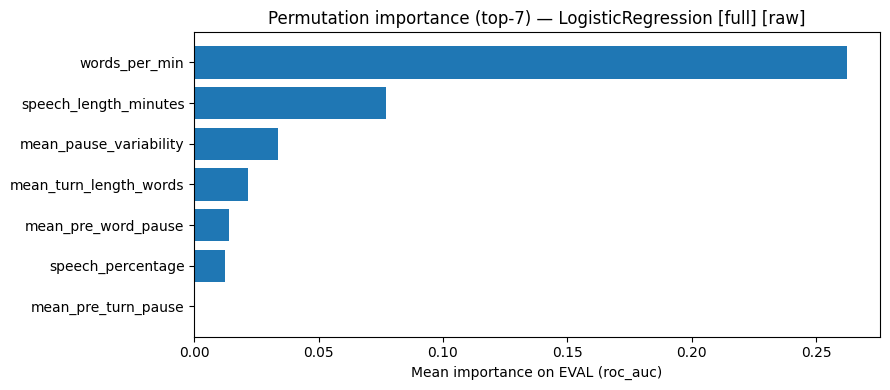


=== LogisticRegression [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Selected cols: ['words_per_min', 'speech_length_minutes', 'mean_pre_word_pause', 'mean_turn_length_words', 'mean_pre_turn_pause']
Train+Dev CV AUC: 0.6322474299893656 +/- 0.06113414785788035

Classification report:
               precision    recall  f1-score   support

           0      0.920     0.657     0.767        35
           1      0.613     0.905     0.731        21

    accuracy                          0.750        56
   macro avg      0.766     0.781     0.749        56
weighted avg      0.805     0.750     0.753        56

Confusion matrix:
 [[23 12]
 [ 2 19]]

[LogisticRegression [selected(top=30,corr<0.9)]] Top-5 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
         words_per_min         0.273061        0.065039
 speech_length_minutes         0.088707        0.022651
m

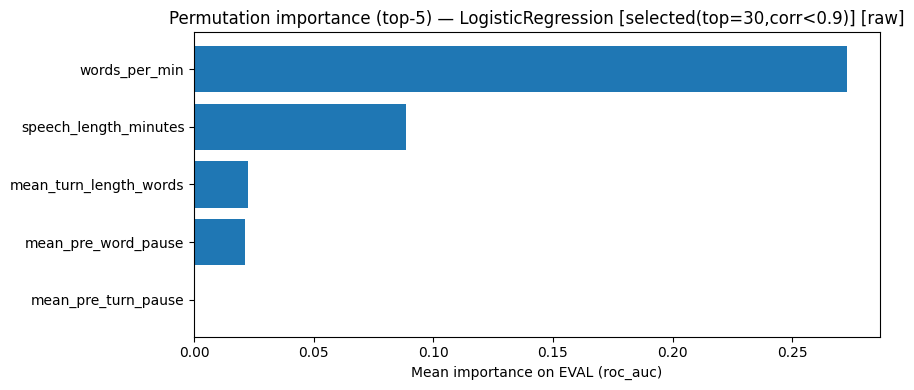


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Train+Dev CV AUC: 0.5651045728465084 +/- 0.11176139082953622

Classification report:
               precision    recall  f1-score   support

           0      0.895     0.486     0.630        35
           1      0.514     0.905     0.655        21

    accuracy                          0.643        56
   macro avg      0.704     0.695     0.642        56
weighted avg      0.752     0.643     0.639        56

Confusion matrix:
 [[17 18]
 [ 2 19]]

[SGDClassifier(log_loss) [full]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
mean_turn_length_words         0.184490        0.061355
         words_per_min         0.127755        0.029780
 speech_length_minutes         0.031973        0.027510
   mean_pre_word_pause         0.028571        0.037729
     speech_percentage         0.010204        0.02

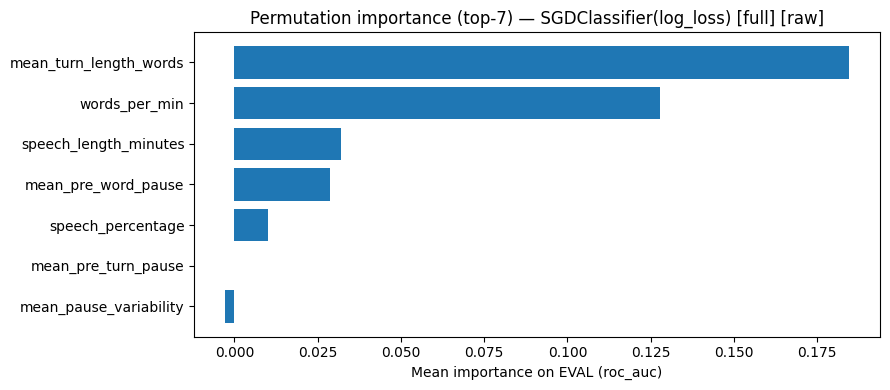


=== SGDClassifier(log_loss) [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Selected cols: ['words_per_min', 'mean_pre_word_pause', 'speech_length_minutes', 'mean_pre_turn_pause', 'mean_turn_length_words']
Train+Dev CV AUC: 0.6187262200165426 +/- 0.07764323281662674

Classification report:
               precision    recall  f1-score   support

           0      0.850     0.486     0.618        35
           1      0.500     0.857     0.632        21

    accuracy                          0.625        56
   macro avg      0.675     0.671     0.625        56
weighted avg      0.719     0.625     0.623        56

Confusion matrix:
 [[17 18]
 [ 3 18]]

[SGDClassifier(log_loss) [selected(top=30,corr<0.9)]] Top-5 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
         words_per_min         0.321088        0.066603
 speech_length_minutes         0.042449        

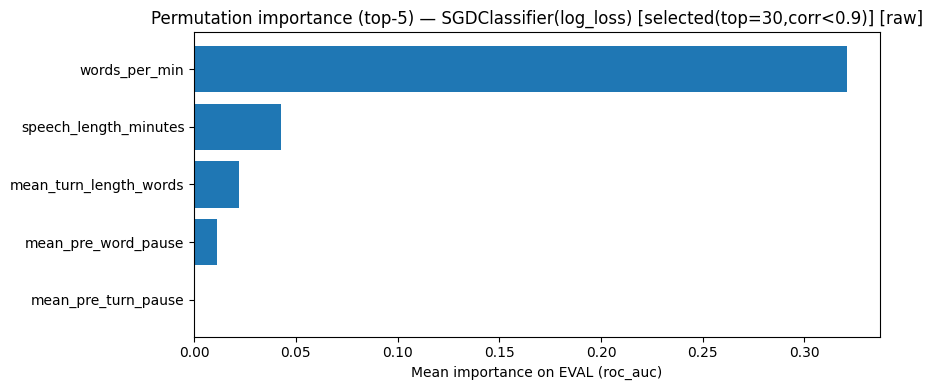

[WARN] DecisionTree[full]: very few unique predicted probabilities (5).

=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Best CV score: 0.625 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.6249562802788609 +/- 0.09414402722756476

Classification report:
               precision    recall  f1-score   support

           0      0.705     0.886     0.785        35
           1      0.667     0.381     0.485        21

    accuracy                          0.696        56
   macro avg      0.686     0.633     0.635        56
weighted avg      0.690     0.696     0.672        56

Confusion matrix:
 [[31  4]
 [13  8]]

[DecisionTree [full_tuned]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
         words_per_min         0.104490        0.063631
mean_pause_variability         0.081088     

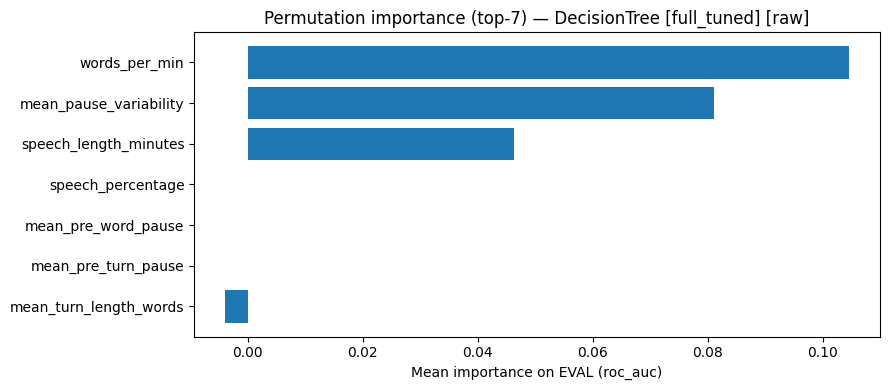

[WARN] DecisionTree[selected]: very few unique predicted probabilities (5).

=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Selected cols: ['speech_percentage', 'words_per_min', 'mean_pause_variability', 'speech_length_minutes', 'mean_pre_turn_pause', 'mean_turn_length_words']
Best CV score: 0.6392 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.6392419945645752 +/- 0.09195751047200018

Classification report:
               precision    recall  f1-score   support

           0      0.705     0.886     0.785        35
           1      0.667     0.381     0.485        21

    accuracy                          0.696        56
   macro avg      0.686     0.633     0.635        56
weighted avg      0.690     0.696     0.672        56

Confusion matrix:
 [[31  4]
 [13  8]]

[DecisionTree [selected_tuned]] Top-6 permutation importances (roc_

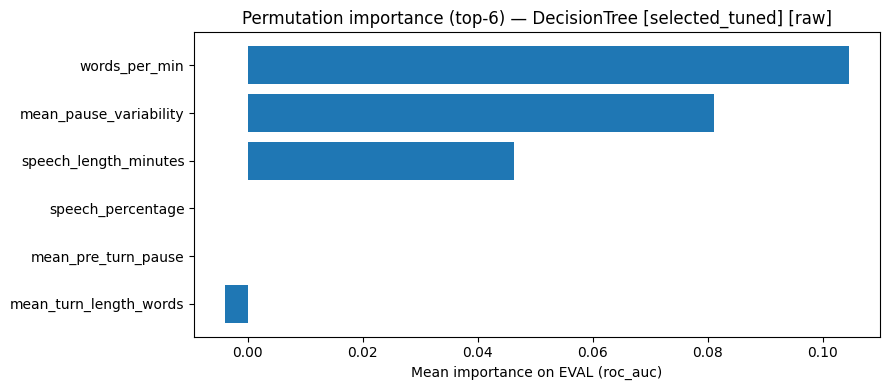


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Best CV score: 0.6125 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Train+Dev CV AUC: 0.6124932057190122 +/- 0.05906992310943284

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.629     0.647        35
           1      0.435     0.476     0.455        21

    accuracy                          0.571        56
   macro avg      0.551     0.552     0.551        56
weighted avg      0.580     0.571     0.575        56

Confusion matrix:
 [[22 13]
 [11 10]]

[RandomForest [full_tuned]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
mean_turn_length_words         0.091429        0.030391
         words_per_min         0.053

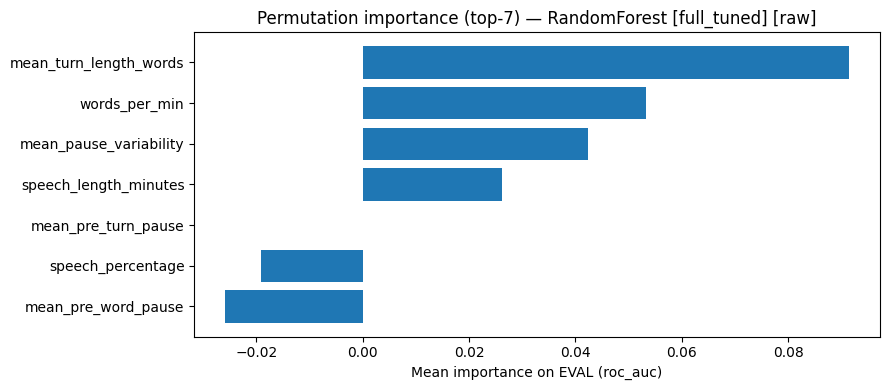


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Selected cols: ['words_per_min', 'speech_length_minutes', 'mean_pre_turn_pause', 'speech_percentage', 'mean_pause_variability', 'mean_turn_length_words']
Best CV score: 0.6118 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
Train+Dev CV AUC: 0.6117676946709205 +/- 0.05985226412273674

Classification report:
               precision    recall  f1-score   support

           0      0.688     0.629     0.657        35
           1      0.458     0.524     0.489        21

    accuracy                          0.589        56
   macro avg      0.573     0.576     0.573        56
weighted avg      0.602     0.589     0.594        56

Confusion matrix:
 [[22 13]
 [10 11]]

[RandomForest [selected_tuned]] Top-6 permutation importances (

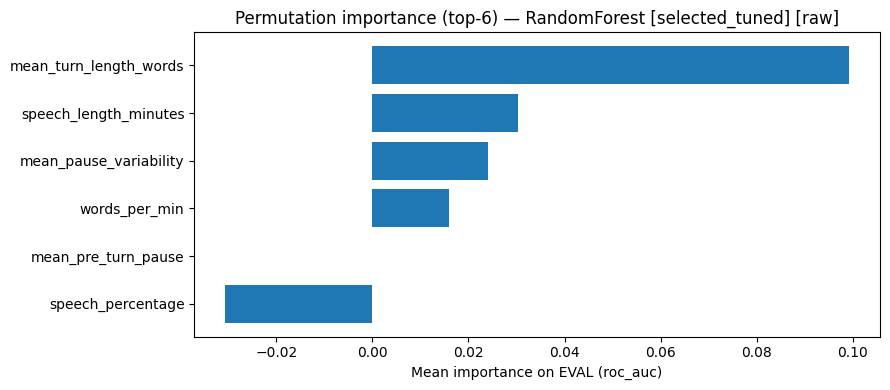


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Best CV score: 0.6308 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV AUC: 0.6307639135058489 +/- 0.06067681532082643

Classification report:
               precision    recall  f1-score   support

           0      0.731     0.543     0.623        35
           1      0.467     0.667     0.549        21

    accuracy                          0.589        56
   macro avg      0.599     0.605     0.586        56
weighted avg      0.632     0.589     0.595        56

Confusion matrix:
 [[19 16]
 [ 7 14]]

[XGBoost [full_tuned]] Top-7 permutation importances (roc_auc, raw):
               feature  importance_mean  importance_std
mean_turn_length_words         0.115782        0.035425
mean_pause_variability 

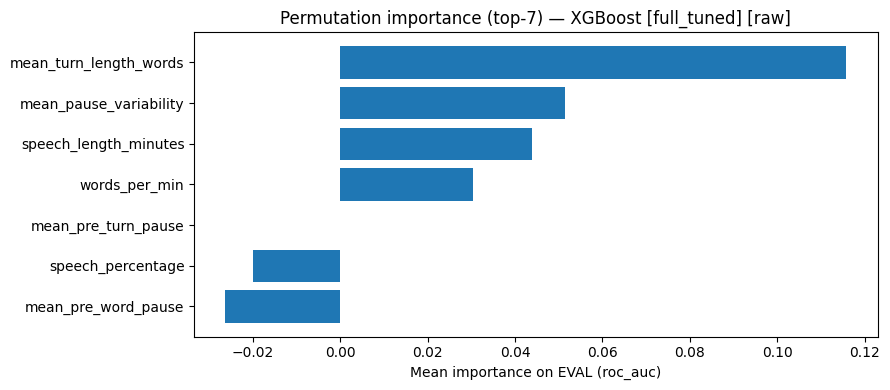


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv) ===
Selected cols: ['words_per_min', 'speech_percentage', 'speech_length_minutes', 'mean_pre_turn_pause', 'mean_pause_variability', 'mean_turn_length_words']
Best CV score: 0.6342 Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV AUC: 0.6341675528772303 +/- 0.07420037697048651

Classification report:
               precision    recall  f1-score   support

           0      0.760     0.543     0.633        35
           1      0.484     0.714     0.577        21

    accuracy                          0.607        56
   macro avg      0.622     0.629     0.605        56
weighted avg      0.656     0.607     0.612        56

Confusion matrix:
 [[19 16]
 [ 6 15]]

[XGBoost [selected_tuned]] Top-6 permutation i

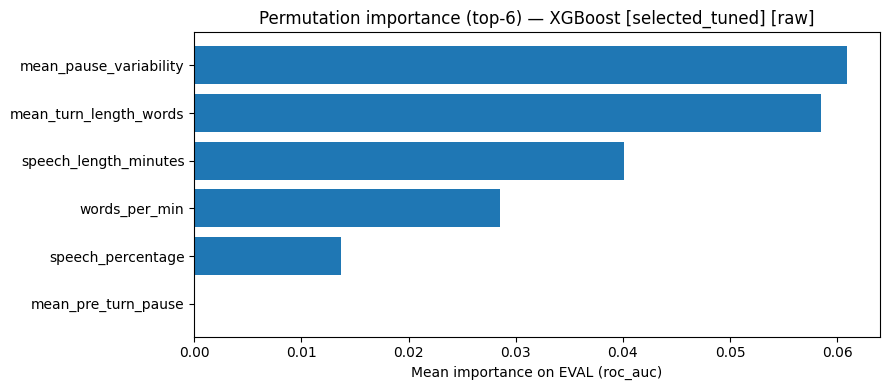


=== Summary metrics on TEST ===
    target                   model                   variant  tuned  cv_best_score  cv_auc_mean  cv_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                                           selected_cols
PTSD_label      LogisticRegression                      full  False            NaN       0.6265      0.0591                                                                                                                                                                                           219      56               7                  NaN    0.6964    0.6963 0.5828 0.8020        0.7381   0.8027  0.6721  0.9143 

In [18]:
res_b0_ptsd = run_models_pipeline_more_models_tuned_rocauc("/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_gemma_ukr_test_small.csv", target_col="PTSD_label")

In [19]:
res_b0_ptsd

,target,model,variant,tuned,cv_best_score,cv_auc_mean,cv_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.626537,0.059100,,219,56,...,0.696332,0.582766,0.801993,0.738095,0.802721,0.672075,0.914320,0.702543,0.215459,
1,PTSD_label,LogisticRegression,"selected(top=30,corr<0.9)",False,NaN,0.632247,0.061134,,219,56,...,0.748718,0.630938,0.854167,0.780952,0.809524,0.684354,0.919728,0.712598,0.212867,"words_per_min,speech_length_minutes,mean_pre_w..."
2,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.565105,0.111761,,219,56,...,0.642401,0.517673,0.750000,0.695238,0.744218,0.597279,0.870748,0.663706,0.317011,
3,PTSD_label,SGDClassifier(log_loss),"selected(top=30,corr<0.9)",False,NaN,0.618726,0.077643,,219,56,...,0.624880,0.500000,0.732057,0.671429,0.778231,0.635374,0.903401,0.718880,0.246121,"words_per_min,mean_pre_word_pause,speech_lengt..."
4,PTSD_label,DecisionTree,full_tuned,True,0.624956,0.624956,0.094144,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.634829,0.499106,0.763713,0.633333,0.693878,0.568707,0.811582,0.517857,0.219296,
5,PTSD_label,DecisionTree,selected_tuned,True,0.639242,0.639242,0.091958,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.634829,0.499106,0.763713,0.633333,0.693878,0.568707,0.811582,0.517857,0.219296,"speech_percentage,words_per_min,mean_pause_var..."
6,PTSD_label,RandomForest,full_tuned,True,0.612493,0.612493,0.059070,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.550802,0.416667,0.684245,0.552381,0.600000,0.448946,0.746939,0.476692,0.241372,
7,PTSD_label,RandomForest,selected_tuned,True,0.611768,0.611768,0.059852,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.572803,0.441980,0.704875,0.576190,0.629932,0.480272,0.775510,0.475723,0.237096,"words_per_min,speech_length_minutes,mean_pre_t..."
8,PTSD_label,XGBoost,full_tuned,True,0.630764,0.630764,0.060677,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",219,56,...,0.585985,0.458065,0.710968,0.604762,0.600000,0.443537,0.738844,0.448431,0.251375,
9,PTSD_label,XGBoost,selected_tuned,True,0.634168,0.634168,0.074200,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",219,56,...,0.605128,0.464286,0.729990,0.628571,0.624490,0.473469,0.763299,0.458660,0.247060,"words_per_min,speech_percentage,speech_length_..."



[INFO] target_col = PTSD_label
[INFO] standardized drop_cols (7): ['Depression_label', 'PTSD_label', 'PTSD_severity', 'Participant', 'age', 'gender', 'split']
[INFO] X_train shape: (219, 20) | X_test shape: (56, 20)
[INFO] class counts train: [153  66] | test: [35 21]

=== LogisticRegression [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Train+Dev CV AUC: 0.6465201465201466 +/- 0.07264943698857529

Classification report:
               precision    recall  f1-score   support

           0      0.733     0.629     0.677        35
           1      0.500     0.619     0.553        21

    accuracy                          0.625        56
   macro avg      0.617     0.624     0.615        56
weighted avg      0.646     0.625     0.631        56

Confusion matrix:
 [[22 13]
 [ 8 13]]

[LogisticRegression [full]] Top-10 permutation importances (roc_auc, raw):
                        feature  importance_mean  importance_std
   

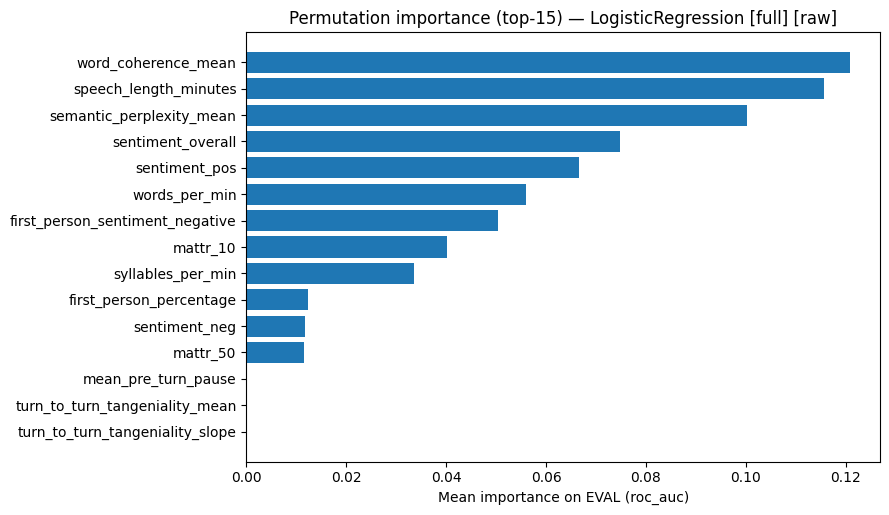


=== LogisticRegression [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Selected cols: ['word_coherence_mean', 'speech_length_minutes', 'mattr_10', 'sentiment_overall', 'first_person_sentiment_negative', 'sentiment_pos', 'semantic_perplexity_mean', 'syllables_per_min', 'sentiment_neg', 'mattr_50', 'words_per_min', 'mean_pause_variability', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'first_person_percentage', 'mean_turn_length_words']
Train+Dev CV AUC: 0.6611839773130096 +/- 0.07649150645577109

Classification report:
               precision    recall  f1-score   support

           0      0.733     0.629     0.677        35
           1      0.500     0.619     0.553        21

    accuracy                          0.625        56
   macro avg      0.617     0.624     0.615        56
weighted avg      0.646     0.625     0.631        56

Confusion matrix

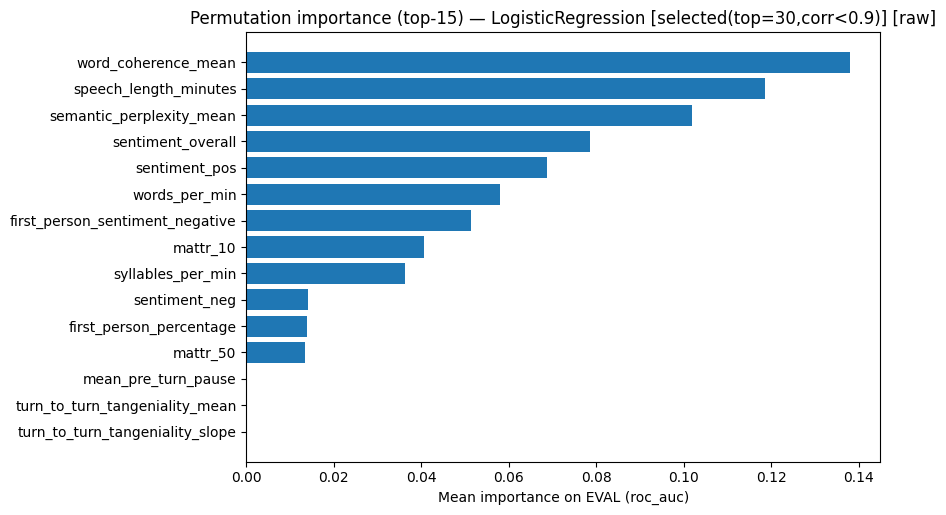


=== SGDClassifier(log_loss) [full] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Train+Dev CV AUC: 0.5465248729764859 +/- 0.039296031023570085

Classification report:
               precision    recall  f1-score   support

           0      0.684     0.743     0.712        35
           1      0.500     0.429     0.462        21

    accuracy                          0.625        56
   macro avg      0.592     0.586     0.587        56
weighted avg      0.615     0.625     0.618        56

Confusion matrix:
 [[26  9]
 [12  9]]

[SGDClassifier(log_loss) [full]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std
                         words_per_min         0.078503        0.024791
                   word_coherence_mean         0.040952        0.025868
                     sentiment_overall         0.024218        0.022618
                              mattr_10 

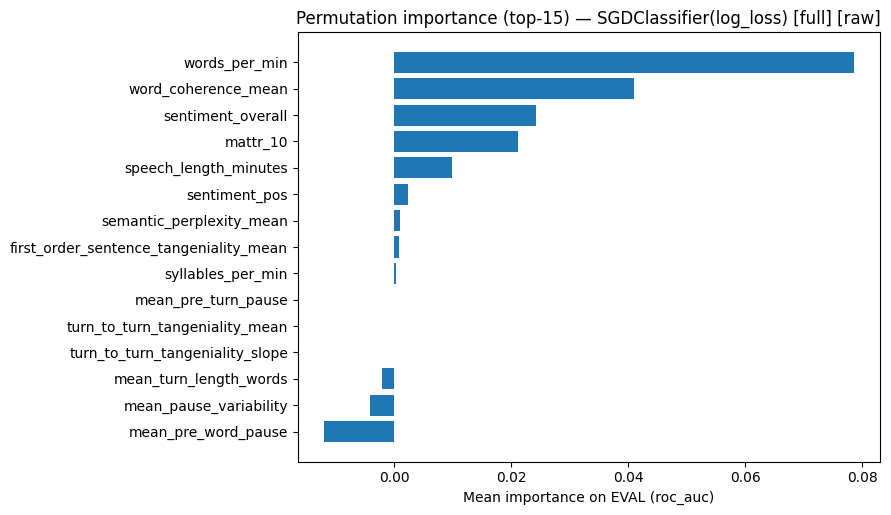


=== SGDClassifier(log_loss) [selected(top=30,corr<0.9)] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Selected cols: ['word_coherence_mean', 'speech_length_minutes', 'mean_pre_word_pause', 'sentiment_overall', 'first_person_sentiment_negative', 'mattr_10', 'semantic_perplexity_mean', 'syllables_per_min', 'words_per_min', 'sentiment_neg', 'sentiment_pos', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'mattr_50', 'mean_turn_length_words', 'first_person_percentage']
Train+Dev CV AUC: 0.6225617393359328 +/- 0.037111394779390884

Classification report:
               precision    recall  f1-score   support

           0      0.667     0.629     0.647        35
           1      0.435     0.476     0.455        21

    accuracy                          0.571        56
   macro avg      0.551     0.552     0.551        56
weighted avg      0.580     0.571     0.575        56

Confusion mat

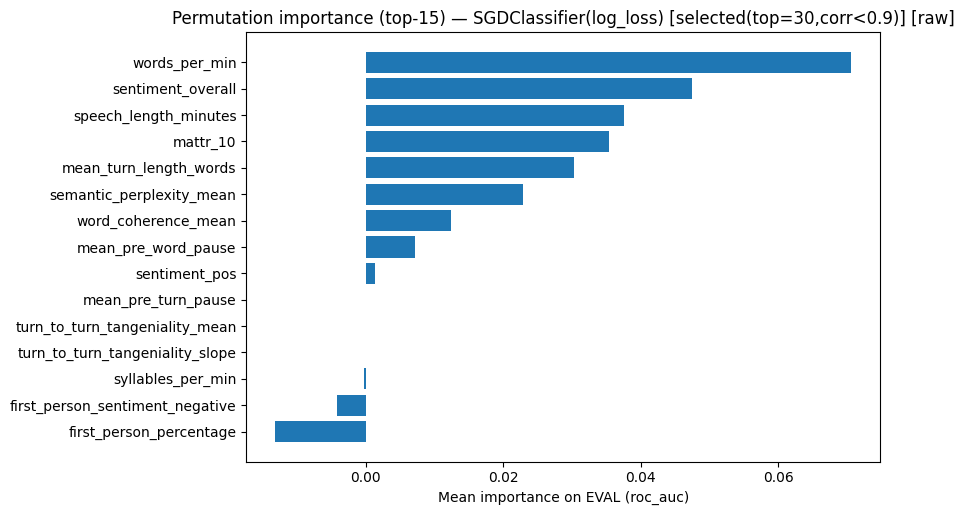

[WARN] DecisionTree[full]: very few unique predicted probabilities (5).

=== DecisionTree [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Best CV score: 0.6048 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.6047961715703651 +/- 0.07552188050906906

Classification report:
               precision    recall  f1-score   support

           0      0.683     0.800     0.737        35
           1      0.533     0.381     0.444        21

    accuracy                          0.643        56
   macro avg      0.608     0.590     0.591        56
weighted avg      0.627     0.643     0.627        56

Confusion matrix:
 [[28  7]
 [13  8]]

[DecisionTree [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                               feature  importance_mean  importance_std
                mean_pause_variability         0.101224        0.056721
        

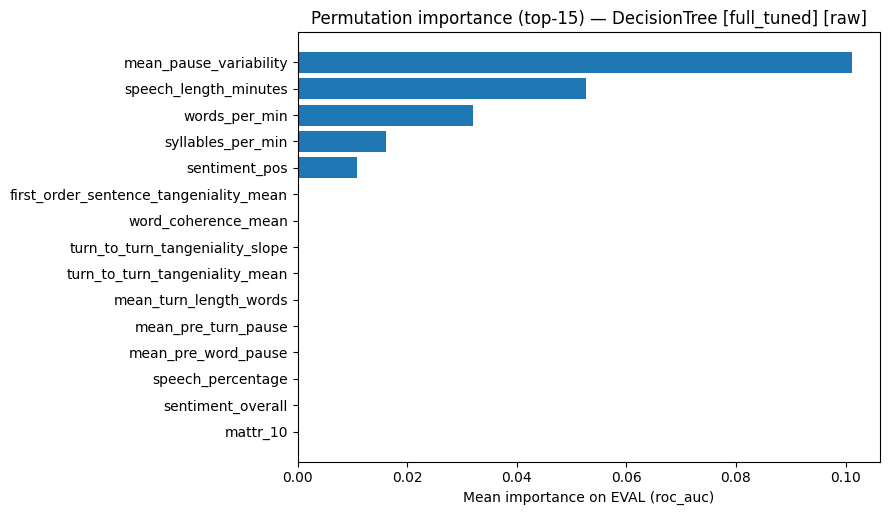

[WARN] DecisionTree[selected]: very few unique predicted probabilities (5).

=== DecisionTree [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Selected cols: ['first_order_sentence_tangeniality_mean', 'first_person_percentage', 'words_per_min', 'syllables_per_min', 'mean_pause_variability', 'mattr_50', 'semantic_perplexity_mean', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'sentiment_neg', 'speech_length_minutes', 'first_person_sentiment_negative', 'sentiment_pos', 'sentiment_overall', 'mattr_10', 'mean_turn_length_words']
Best CV score: 0.6078 Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Train+Dev CV AUC: 0.607757296466974 +/- 0.07316100359447669

Classification report:
               precision    recall  f1-score   support

           0      0.690     0.829     0.753        35
           1      0.571     0.381     0.457

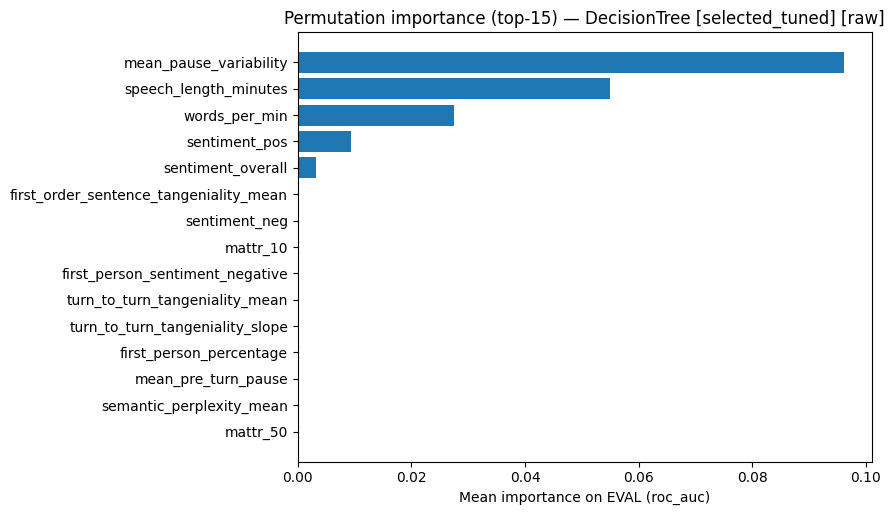


=== RandomForest [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Best CV score: 0.5946 Best params: {'clf__bootstrap': True, 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}
Train+Dev CV AUC: 0.5945811178069242 +/- 0.06125831660647852

Classification report:
               precision    recall  f1-score   support

           0      0.628     0.771     0.692        35
           1      0.385     0.238     0.294        21

    accuracy                          0.571        56
   macro avg      0.506     0.505     0.493        56
weighted avg      0.537     0.571     0.543        56

Confusion matrix:
 [[27  8]
 [16  5]]

[RandomForest [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                        feature  importance_mean  importance_std
         mean_turn_length_words         0.073197        0.030922
         mean_

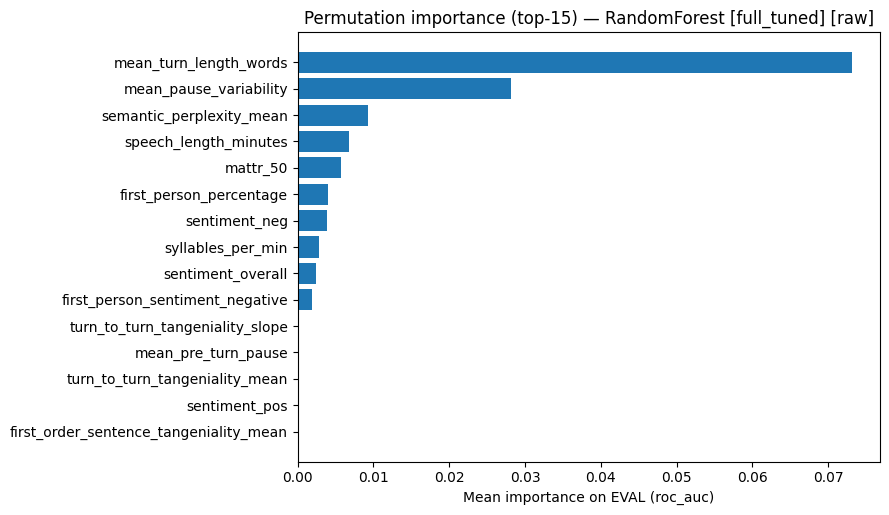


=== RandomForest [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Selected cols: ['speech_length_minutes', 'words_per_min', 'word_coherence_mean', 'sentiment_neg', 'first_person_percentage', 'sentiment_pos', 'speech_percentage', 'sentiment_overall', 'turn_to_turn_tangeniality_slope', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'syllables_per_min', 'mean_pause_variability', 'semantic_perplexity_mean', 'mattr_10', 'first_person_sentiment_negative', 'mean_turn_length_words', 'mattr_50']
Best CV score: 0.5995 Best params: {'clf__bootstrap': True, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}
Train+Dev CV AUC: 0.5995332624364883 +/- 0.07305583568866708

Classification report:
               precision    recall  f1-score   support

           0      0.718     0.800     0.757        35
           1      0.588     0.476   

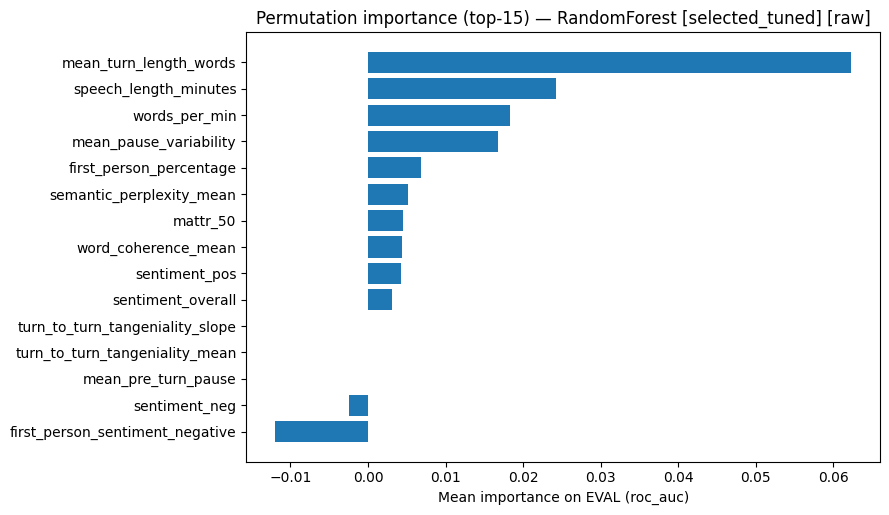


=== XGBoost [full_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Best CV score: 0.5976 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__min_child_weight': 1, 'clf__n_estimators': 200, 'clf__reg_lambda': 1.0, 'clf__subsample': 1.0}
Train+Dev CV AUC: 0.597637953444405 +/- 0.08090880648890009

Classification report:
               precision    recall  f1-score   support

           0      0.694     0.714     0.704        35
           1      0.500     0.476     0.488        21

    accuracy                          0.625        56
   macro avg      0.597     0.595     0.596        56
weighted avg      0.622     0.625     0.623        56

Confusion matrix:
 [[25 10]
 [11 10]]

[XGBoost [full_tuned]] Top-10 permutation importances (roc_auc, raw):
                 feature  importance_mean  importance_std
  mean_pause_variability         0.064082        0.019245
semantic_perplexi

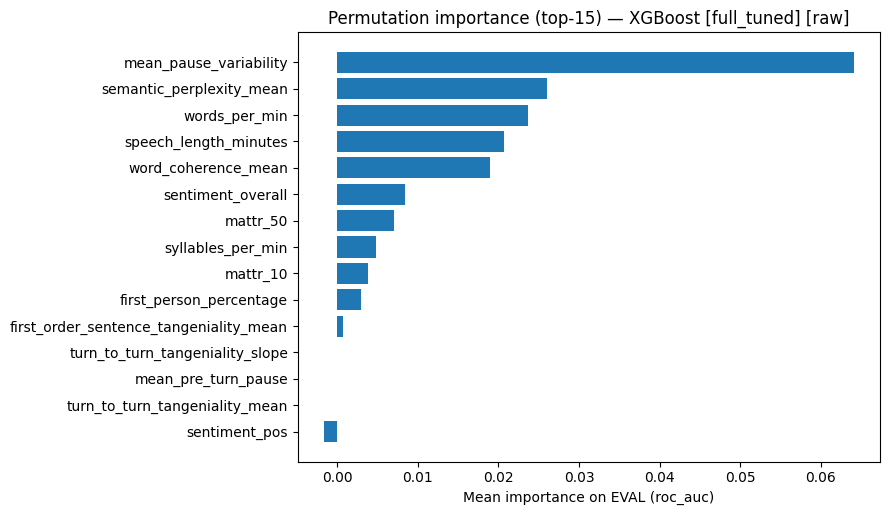


=== XGBoost [selected_tuned] (/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv) ===
Selected cols: ['words_per_min', 'speech_length_minutes', 'sentiment_pos', 'mean_pause_variability', 'word_coherence_mean', 'speech_percentage', 'sentiment_neg', 'first_person_percentage', 'semantic_perplexity_mean', 'sentiment_overall', 'mattr_10', 'mean_pre_turn_pause', 'turn_to_turn_tangeniality_mean', 'turn_to_turn_tangeniality_slope', 'first_person_sentiment_negative', 'mean_turn_length_words', 'syllables_per_min', 'mattr_50']
Best CV score: 0.5978 Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 500, 'clf__reg_lambda': 5.0, 'clf__subsample': 1.0}
Train+Dev CV AUC: 0.5977797471345859 +/- 0.08295807415226744

Classification report:
               precision    recall  f1-score   support

           0      0.625     0.714     0.667        35
           1      0

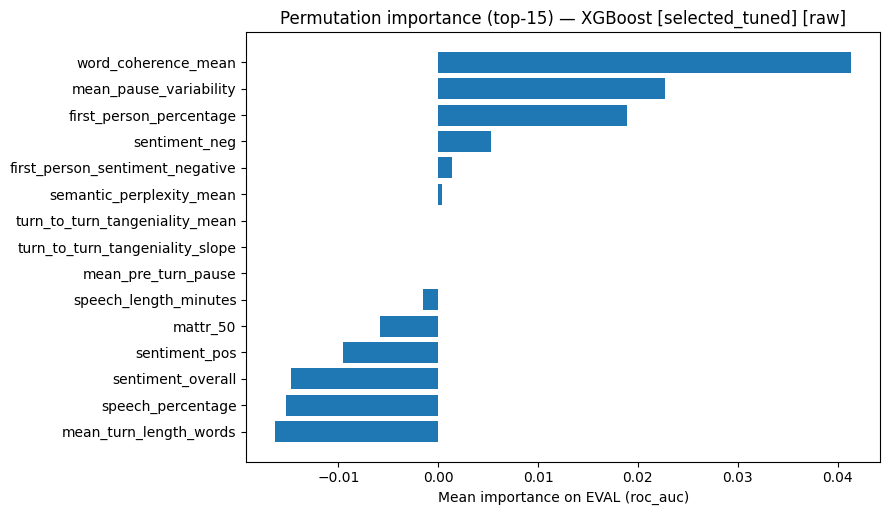


=== Summary metrics on TEST ===
    target                   model                   variant  tuned  cv_best_score  cv_auc_mean  cv_auc_std                                                                                                                                                                          best_params  n_train  n_test  n_features_raw  n_features_selected  accuracy  f1_macro  f1_lo  f1_hi  balanced_acc  roc_auc  auc_lo  auc_hi  pr_auc  brier                                                                                                                                                                                                                                                                                                                                                                  selected_cols
PTSD_label      LogisticRegression                      full  False            NaN       0.6465      0.0726                                                              

In [20]:
res_b0_l_ptsd = run_models_pipeline_more_models_tuned_rocauc("/Users/pelmeshek1706/Desktop/projects/airest_notebooks/data/dataset_B0_plus_L_gemma_ukr_small.csv", target_col="PTSD_label")

In [21]:
res_b0_l_ptsd

,target,model,variant,tuned,cv_best_score,cv_auc_mean,cv_auc_std,best_params,n_train,n_test,...,f1_macro,f1_lo,f1_hi,balanced_acc,roc_auc,auc_lo,auc_hi,pr_auc,brier,selected_cols
0,PTSD_label,LogisticRegression,full,False,NaN,0.646520,0.072649,,219,56,...,0.615057,0.477981,0.741829,0.623810,0.740136,0.593197,0.865306,0.677635,0.209748,
1,PTSD_label,LogisticRegression,"selected(top=30,corr<0.9)",False,NaN,0.661184,0.076492,,219,56,...,0.615057,0.477981,0.741829,0.623810,0.744218,0.597279,0.868027,0.688962,0.208857,"word_coherence_mean,speech_length_minutes,matt..."
2,PTSD_label,SGDClassifier(log_loss),full,False,NaN,0.546525,0.039296,,219,56,...,0.586934,0.455135,0.716886,0.585714,0.661224,0.507449,0.801395,0.612545,0.351418,
3,PTSD_label,SGDClassifier(log_loss),"selected(top=30,corr<0.9)",False,NaN,0.622562,0.037111,,219,56,...,0.550802,0.416667,0.679137,0.552381,0.670748,0.518367,0.812279,0.633494,0.387127,"word_coherence_mean,speech_length_minutes,mean..."
4,PTSD_label,DecisionTree,full_tuned,True,0.604796,0.604796,0.075522,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.590643,0.450980,0.721195,0.590476,0.657143,0.519711,0.780306,0.545996,0.220744,
5,PTSD_label,DecisionTree,selected_tuned,True,0.607757,0.607757,0.073161,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",219,56,...,0.605195,0.467836,0.737658,0.604762,0.674150,0.544201,0.797959,0.551062,0.214418,"first_order_sentence_tangeniality_mean,first_p..."
6,PTSD_label,RandomForest,full_tuned,True,0.594581,0.594581,0.061258,"{'clf__bootstrap': True, 'clf__max_depth': 10,...",219,56,...,0.493213,0.362602,0.620868,0.504762,0.678912,0.530612,0.814966,0.554419,0.211984,
7,PTSD_label,RandomForest,selected_tuned,True,0.599533,0.599533,0.073056,"{'clf__bootstrap': True, 'clf__max_depth': 5, ...",219,56,...,0.641536,0.499187,0.766667,0.638095,0.680272,0.533299,0.817687,0.544662,0.216882,"speech_length_minutes,words_per_min,word_coher..."
8,PTSD_label,XGBoost,full_tuned,True,0.597638,0.597638,0.080909,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",219,56,...,0.596015,0.461360,0.727778,0.595238,0.614966,0.451667,0.766020,0.549850,0.235967,
9,PTSD_label,XGBoost,selected_tuned,True,0.597780,0.597780,0.082958,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",219,56,...,0.495495,0.366516,0.619910,0.500000,0.557823,0.393163,0.708878,0.508209,0.279620,"words_per_min,speech_length_minutes,sentiment_..."
